# Notebook for running the pipeline for the recovery of $V(\phi)$ from the second branch (SB) data + attaching the pretrained model from first branch (FB) data #

Run the $\texttt{SB\_train\_model.py}$ for loading a pretrained model, continue training, or training from scratch

If only visualization and/or inspection of a pretrained model is wanted, comment the training lines (indicated in the .py) and just keep the loading lines.

Using random seed: 3001730035
File is .txt


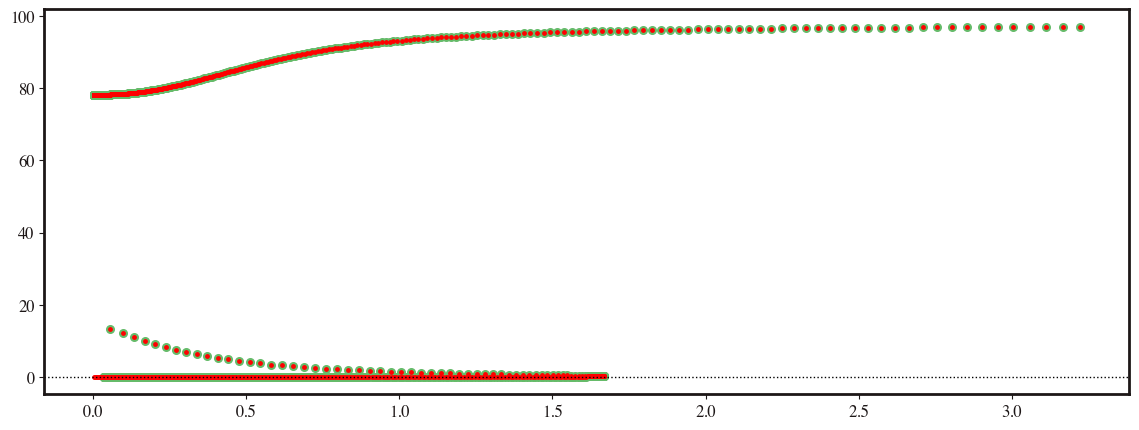

539
607
indx_init_SB 0


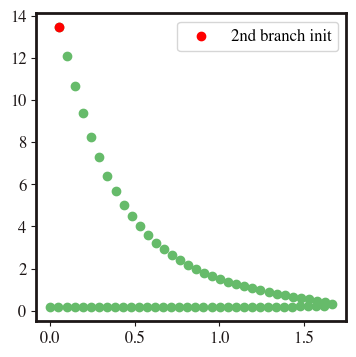

Check device tensor(-0.6752)
From self.V1:  V1(0)= -2.9997906608052824  DV1(0)= 0.0008554927198361578  DDV1(0)= -2.9967480241294173
Loaded new FB state dict for V1
Different phi_c from FB and SB NNs -- Taking FB value!
Loaded second branch V network parameters
loaded new FB (forced V(0), DV(0), DDV(0) FB net)
From self.V.FB:  V1(0)= -2.999782551175364  DV1(0)= 0.0009122916102541865  DDV1(0)= -2.999567516137463
Loaded Optimizer State
Above phi_c ADD LOSS Active!
V_min addloss Active!
DV_min addloss Active!
DDV_min addloss Active!
Vth_min =  -214.73037848647948  at phi =  2.407740774077408
DVth_min =  0.05066724227611556
DDVth_min =  3224.417162055927
Loaded previous addlosses from SB training
best nets not None
best nets not None
best nets not None
best nets not None
best nets not None
best nets not None
Loaded second branch solver nets state
NNHolo initialized
inside beg
Actual learning rate:  1.478272866694203e-06
1.478272866694203e-06
inside end


Epochs: 0iteration [00:00, ?iteration/s]
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Model succesfully saved
S_min:  tensor(1.6086e-10)
Length of input s(T) curve:  torch.Size([70])


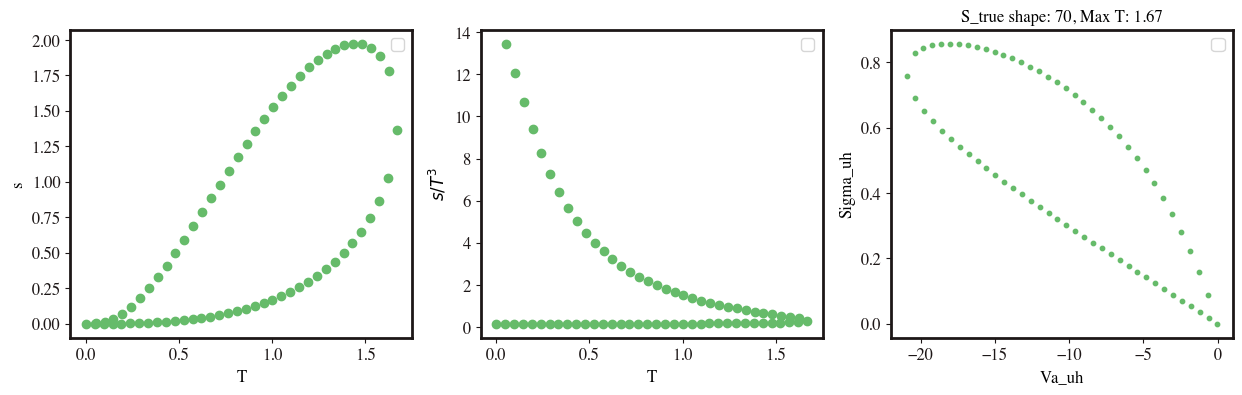

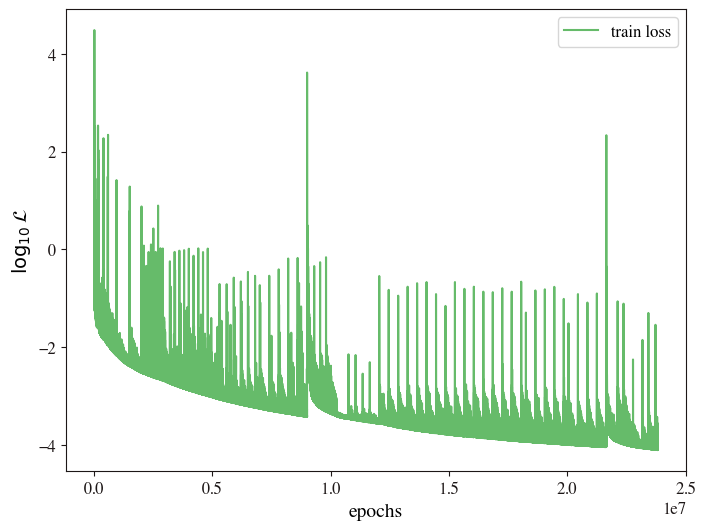

Min loss:  7.944122641767041e-05


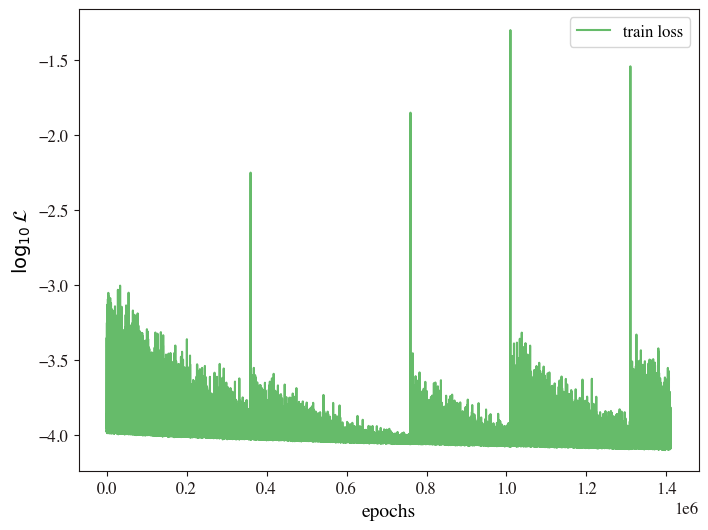

Min loss:  7.944122641767041e-05
max phi_h=  2.398090755355619
[1.30564381 1.48221501 1.58218465 1.64547029 1.70938268 1.76975573
 1.81633315 1.84419529 1.86766613 1.88951506 1.90717465 1.9266895
 1.94598485 1.96361778 1.98256268 1.99963197 2.01690453 2.03341282
 2.05129533 2.06675136 2.08306561 2.10034041 2.11658295 2.13214767
 2.14829196 2.16537348 2.18058611 2.19836543 2.21446838 2.23110968
 2.24982964 2.26780342 2.28503627 2.30995323 2.34935422 2.37315648
 2.38017036 2.38298241 2.38564425 2.38785608 2.38939663 2.39114144
 2.39257811 2.39344892 2.39415258 2.39471615 2.39506041 2.39531385
 2.39547712 2.39554333 2.39560105 2.39562928 2.39559738 2.39557239
 2.39556529 2.39551105 2.39541911 2.39530913 2.39513465 2.3948888
 2.39456388 2.39437455 2.39424235 2.39048231 2.00239728 1.73163289
 1.59434197 1.372381   1.32272449 2.39809076]


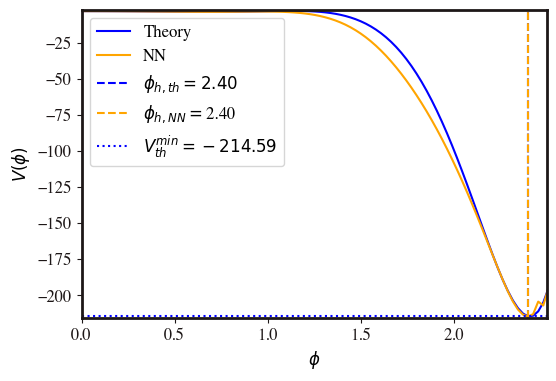

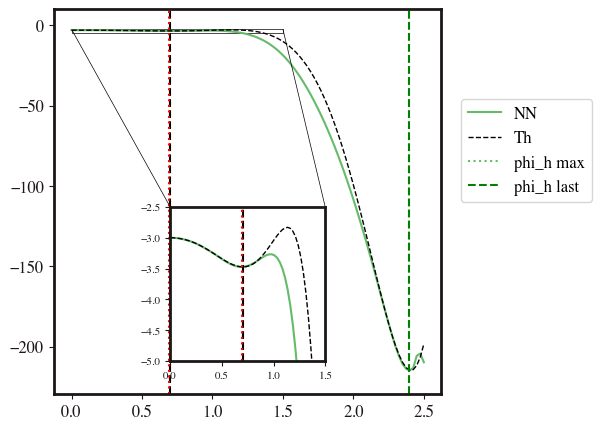

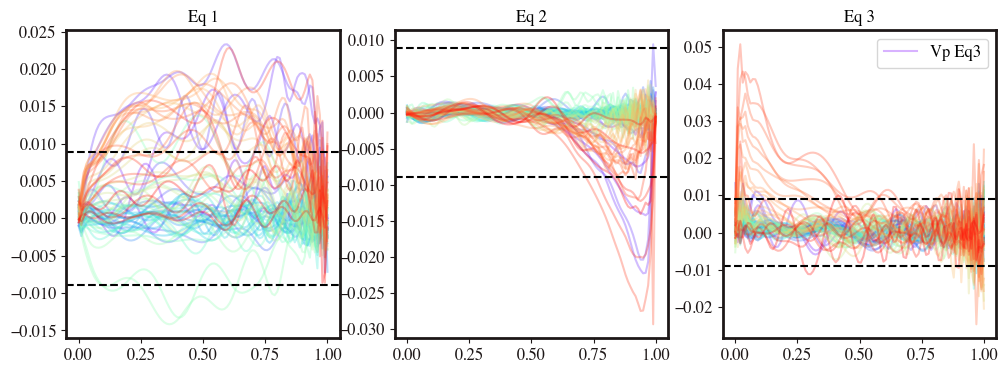

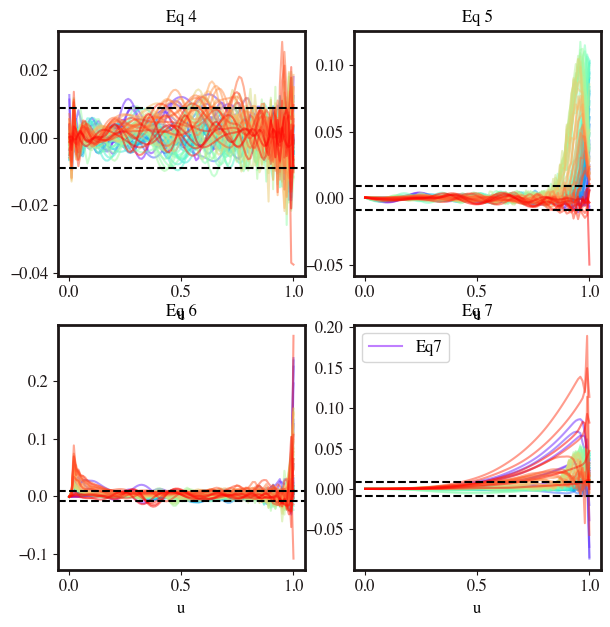

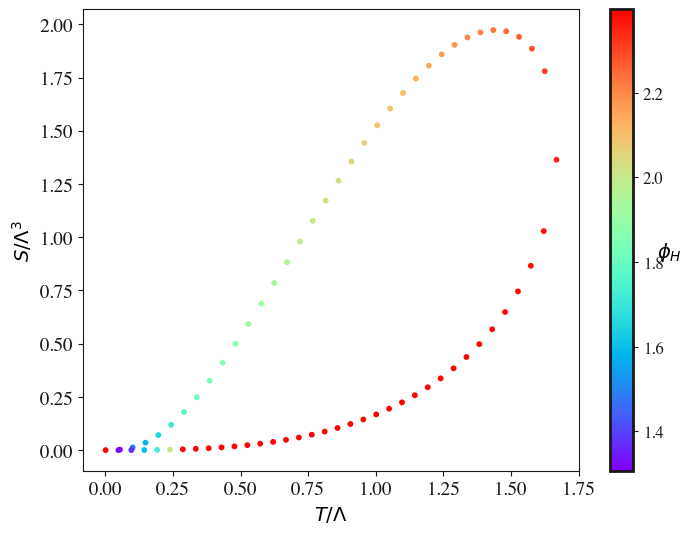

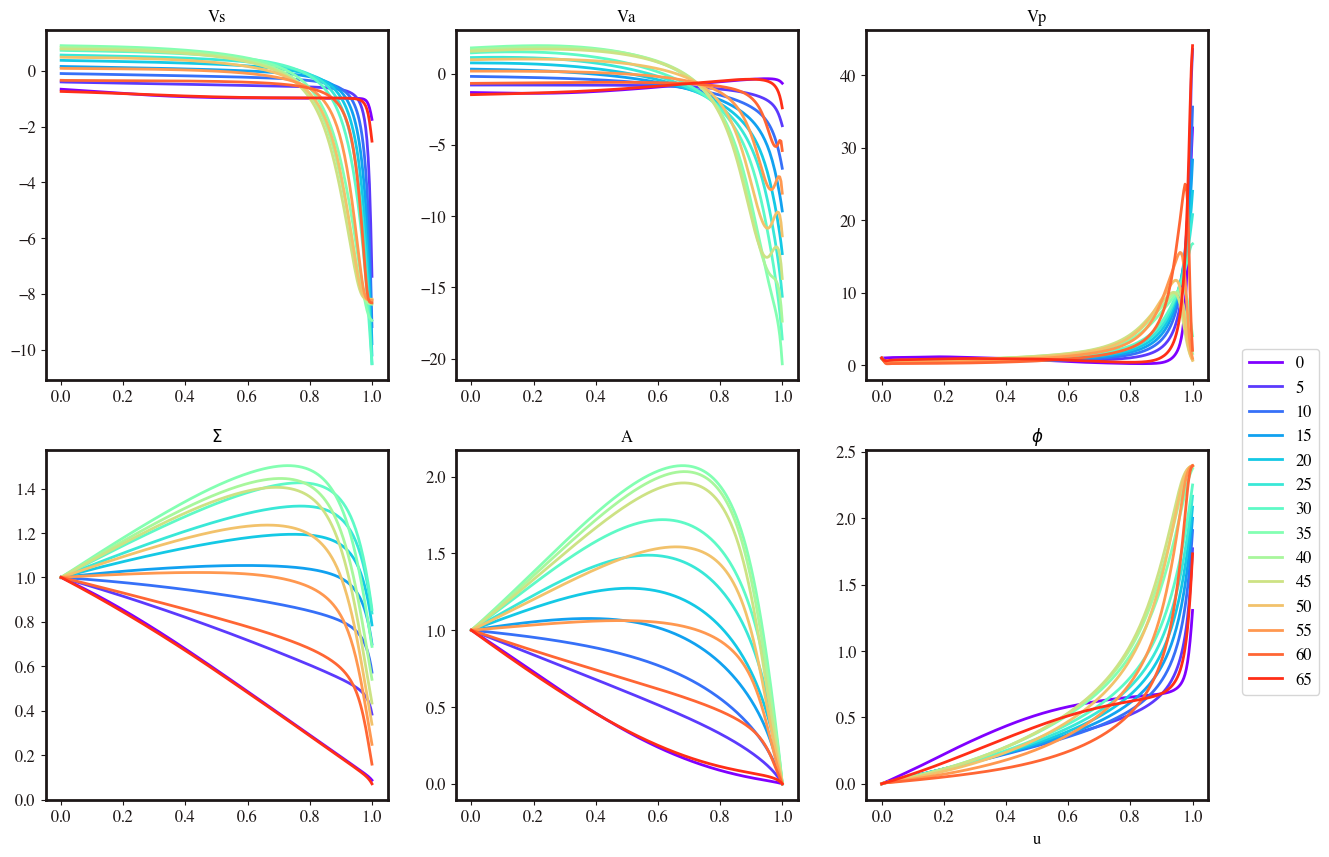

RE 0.22520089776909397


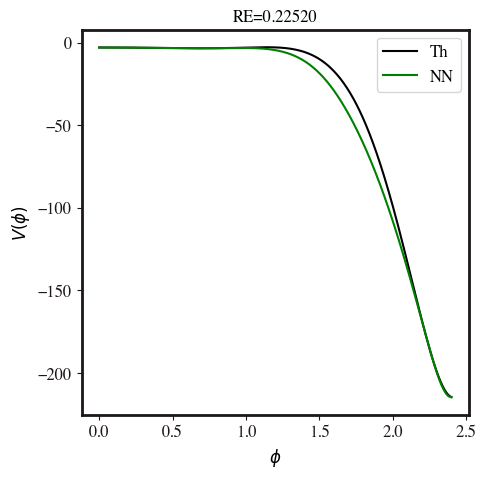

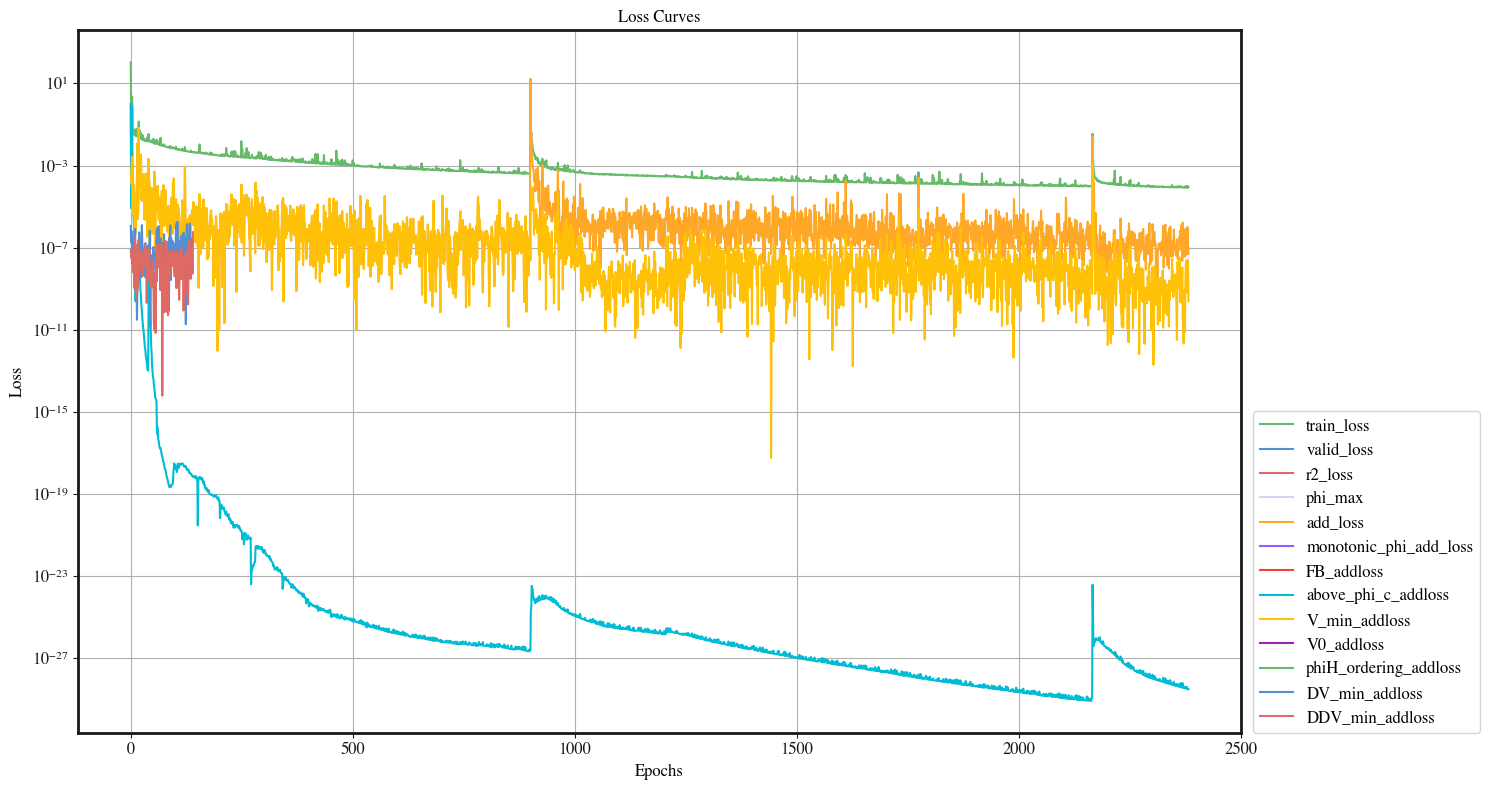

inside beg
Actual learning rate:  1.478272866694203e-06
1.478272866694203e-06
inside end
0.05960094083333334 horas


In [1]:
%run SB_train_model.py

In [3]:
c.save_results(f'{path_results}/SB_results_from_scratch')

Model succesfully saved


## Visualize the results and interact with the loaded model

In [2]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 16,
    'axes.labelsize': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'mathtext.fontset': 'dejavusans'
})

In [3]:
parent_dir = parent_dir

plots_dir = f'{parent_dir}/plots/'
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)

phim_str = '0_55'

type_str_for_saving = 'test_1'
approx_epoch_num = '23M'

model = c


In [4]:
c.solver.global_epoch

23828610

### Loss function

r2_loss
DV_min_addloss
DDV_min_addloss


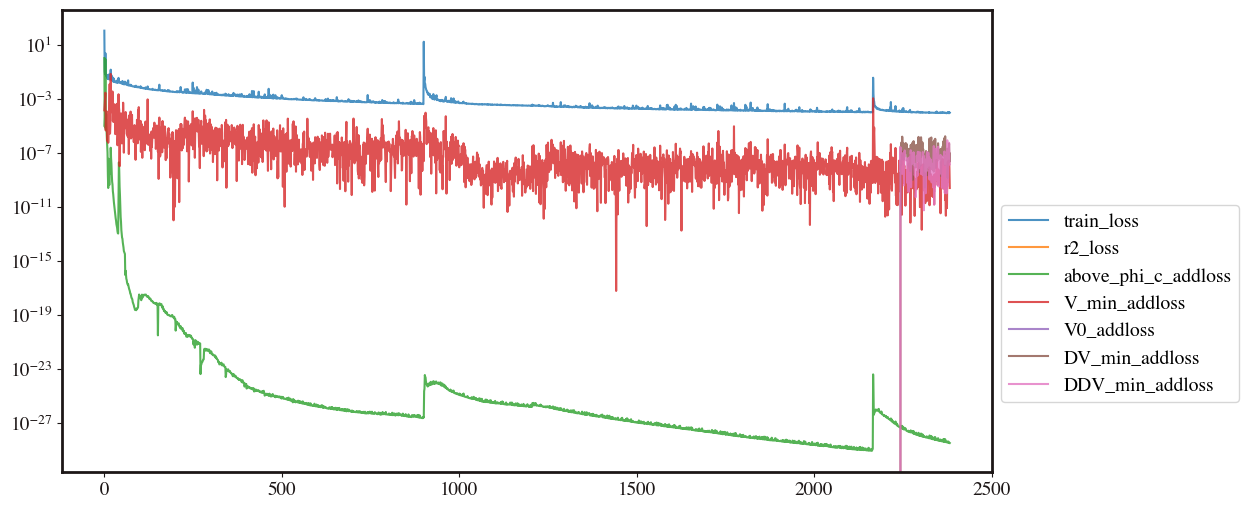

In [5]:
loss = c.solver.metrics_history

to_plot_list = ["train_loss",
                "r2_loss",
                "above_phi_c_addloss",
                "V_min_addloss",
                "V0_addloss",
                # "phiH_ordering_addloss",
                "DV_min_addloss",
                "DDV_min_addloss",
]

colors = plt.cm.tab10(range(len(to_plot_list)))


step = 10000 # personalize for better visualization
fig = plt.figure(figsize = (12,6))
for i, key in enumerate(to_plot_list):

    if len(loss[key])<len(loss['train_loss']):
        print(key)
        loss_plt = loss[key]
        loss_plt = [0]*int(len(loss['train_loss']) - len(loss[key])) + loss_plt
    else:
        loss_plt = loss[key]

    plt.plot(loss_plt[::step], label = f'{key}', alpha = 0.8, color = colors[i])
    
plt.legend(loc=(1.01,0.15))
plt.yscale('log')
plt.show()

### $V(\phi)$ potential (quick diagnosis)

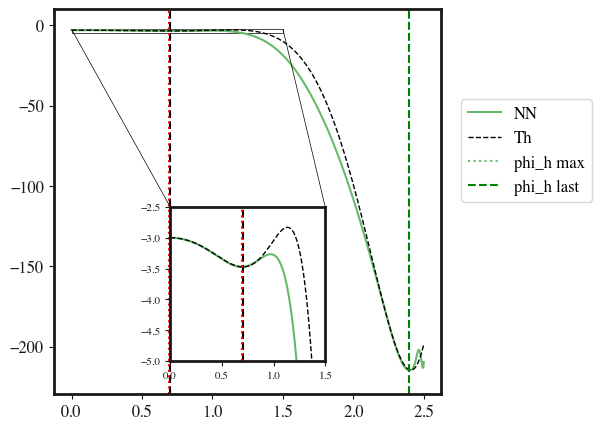

In [ ]:
model.plot_potential_new(save_fig=False, phim=0.55, n_points=1000)

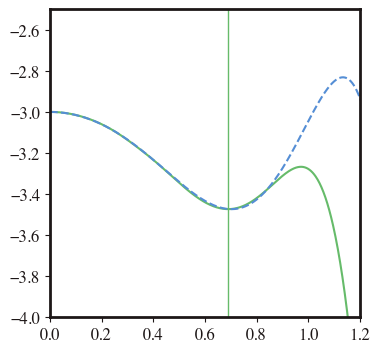

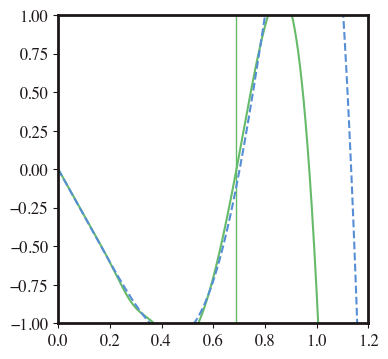

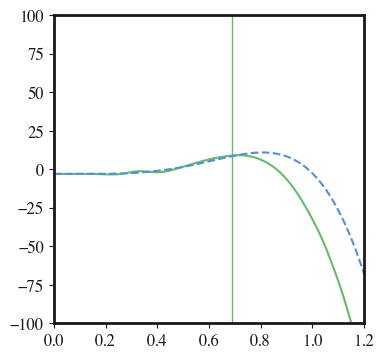

In [ ]:
phi=torch.linspace(0.0,1.5, 1000).reshape(-1,1)

V_nn = c.V(phi).detach().numpy().reshape(-1,)
DV_nn = np.gradient(V_nn.reshape(-1,), phi.detach().numpy().reshape(-1,)) 
DDV_nn= np.gradient(DV_nn.reshape(-1,), phi.detach().numpy().reshape(-1,))

phi_np = phi.detach().numpy().reshape(-1,)
Vnn_np = V_nn


phi_th = np.linspace(0,1.5,1000)
V_th = V_or(phi_th, phim=0.55)


plt.figure()
plt.axvline(c.phi_c, linewidth=1)
plt.plot(phi_np, Vnn_np, label='NN')
plt.plot(phi_th, V_th, '--', label='Th')
plt.xlim(0,1.2)
plt.ylim(bottom=-4, top=-2.5)
plt.show()

plt.figure()
plt.axvline(c.phi_c, linewidth=1)

plt.plot(phi_np, DV_nn, label='NN')
plt.plot(phi_th, DV_or(phi_th, phim=0.55), '--', label='Th')
plt.xlim(0,1.2)
plt.ylim(bottom = -1, top= 1)
plt.show()

plt.figure()
plt.axvline(c.phi_c, linewidth=1)

plt.plot(phi_np, DDV_nn, label='NN')
plt.plot(phi_th,  DDV_or(phi_th, phim=0.55), '--', label='Th')
plt.xlim(0,1.2)
plt.ylim(bottom=-100, top=100)
plt.show()

# print('V(0)', float(V_nn[0]))
# print('DV(0)', float(DV_nn[0]))
# print('DDV(0)', float(DDV_nn[0]))

In [ ]:
phi=torch.tensor([0.0], requires_grad=True).reshape(-1,1)

V_nn = c.V(phi)
DV_nn = diff(V_nn, phi, order=1)
DDV_nn= diff(DV_nn, phi, order=1)

print('V(0)', float(V_nn[0]), 'diff=', f'{float(V_nn[0]) - (-3):.3e}')
print('DV(0)', float(DV_nn[0]), 'diff=', f'{float(DV_nn[0]) - (0):.3e}')
print('DDV(0)', float(DDV_nn[0]), 'diff=', f'{float(DDV_nn[0]) - (-3):.3e}')

V(0) -2.9997825511753637 diff= 2.174e-04
DV(0) 0.0009122916102540843 diff= 9.123e-04
DDV(0) -2.999567516137463 diff= 4.325e-04


#### Save potential for direct problem

In [ ]:

phim=0.55

trained_epochs = len(c.solver.metrics_history['train_loss'])

u = np.linspace(0.0001, 1, 1000)
solution = c.solver.get_solution(best=True)
phi_h = np.ones(c.S_true.shape)
true_phi_h = np.ones(c.S_true.shape)
u_max = np.ones(c.S_true.shape)

for i,S in enumerate(c.S_true):
    T=c.T_true[i]
#    print(i,S,T)
    Sigma_v = c.Sigma_uh_all[i]
    Va_v = c.Va_uh_all[i]
    Z = c.Z[i].cpu().detach().numpy()*np.ones_like(u)
    Sigma_uh = Sigma_v.cpu().detach().numpy()*np.ones_like(u)
    Va_uh = Va_v.cpu().detach().numpy()*np.ones_like(u)
    Vs, Va, Vp, Sigma, A, phi = solution(u, Sigma_uh,  Va_uh, Z,to_numpy=True)
    phi_h[i] = phi.max()
    true_phi_h[i] = phi[-1]
    i_max = phi.argmax()
    u_max[i] = u[i_max]
print('max phi_h= ',max(phi_h))



personalized_sampling = False

for i, model in enumerate(models_list):

    c = model

    trained_epochs = loop_idx_list[i]

    list_points = [100, 500, 1000, 5000]

    for n_points in list_points:

        # Define the domain of input phi

        if personalized_sampling ==True:
            joint = 2.1

            phi_1= np.linspace(0,joint,100)
            phi_2 = np.linspace(joint + (joint/70), max(phi_h)+0.3, 100)


            phi_personalized = np.concatenate([phi_1, phi_2])
            n_points = len(phi_personalized)

            phi = torch.Tensor(phi_personalized).reshape(-1,1)

        else:
            phi=torch.reshape(torch.linspace(0,max(phi_h)+0.3, n_points),[n_points,1])

        phi.requires_grad = True
        qphi = phi.cpu().detach().numpy().reshape(-1,)


        Vv = c.V(phi)
        DVv = diff(Vv, phi, shape_check= False)
        DDVv = diff(Vv, phi, order=2, shape_check= False)

        py_listphi=phi.tolist()
        py_listV=Vv.tolist()
        py_listDV=DVv.tolist()
        py_listDDV=DDVv.tolist()

        # potentialV=pd.DataFrame(list(zip(py_listphi, py_listV)),columns=['Phi','V'])
        potentialV=pd.DataFrame(list(zip(py_listphi,py_listV,py_listDV,py_listDDV)),columns=['Phi','V','DV','DDV'])

        potentialV['Phi']=potentialV['Phi'].str[0]
        potentialV['V']=potentialV['V'].str[0]
        potentialV['DV']=potentialV['DV'].str[0]
        potentialV['DDV']=potentialV['DDV'].str[0]

        if personalized_sampling:
            potentialV.to_csv(f'{c.path}/V_epoch_{trained_epochs}_{n_points}_pts_personalized_sampling.csv', index=False)
        else:
            potentialV.to_csv(f'{c.path}/V_epoch_{approx_epoch_num}_{n_points}_pts_.csv', index=False)




max phi_h=  2.4211842912031725


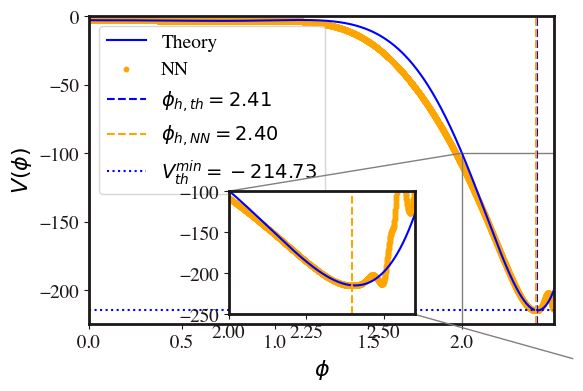

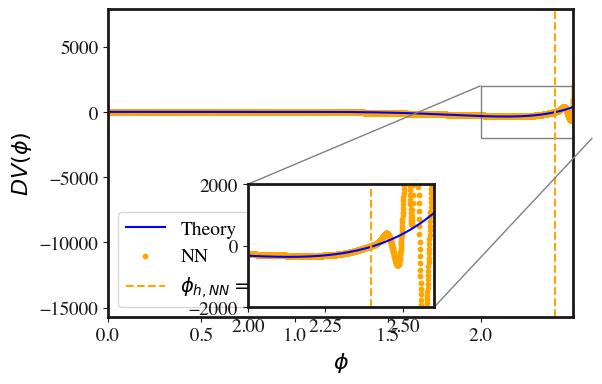

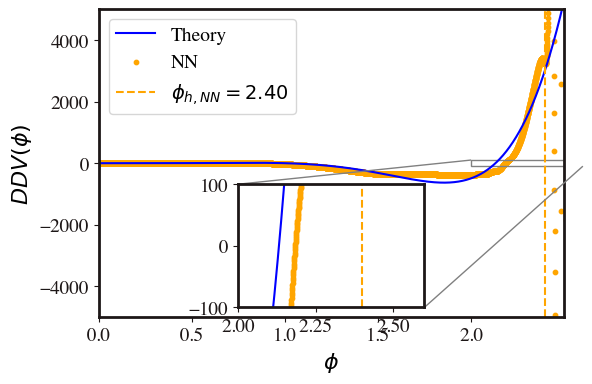

In [ ]:
x1, x2 = 2.0, 2.6   # zoom region in x

# YOU tweak these:
y1_V, y2_V   = -250, -100      # for V
y1_DV, y2_DV = -2000, 2000     # for DV
y1_DDV, y2_DDV = -100, 100  # for DDV


fig2, ax = plt.subplots(figsize=(6,4))

ax.plot(qphi, V_or(qphi, phim), color='blue', label='Theory')
ax.scatter(qphi, Vv.cpu().detach(), label='NN', color='orange', s=10)

phi_h_th = qphi[np.argmin(V_or(qphi, phim))]

ax.axvline(phi_h_th, color='blue', linestyle='dashed', label=r'$\phi_{h,th}=%.2f$'%phi_h_th)
ax.axvline(max(phi_h), label=r'$\phi_{h,NN}=%.2f$'%max(phi_h), color='orange', linestyle='dashed')
ax.axhline(min(V_or(qphi, phim)), color='blue', linestyle='dotted',
           label=r'$V_{th}^{min}=%.2f$'%min(V_or(qphi,phim)))

ax.set_xlim((0, max(phi_h)+0.1))
ax.set_ylim((min(V_or(qphi,phim))-10, 0))
ax.set_xlabel(r'$\phi$')
ax.set_ylabel(r'$V(\phi)$')
ax.legend()

# --- inset ---
axins = inset_axes(ax, width="40%", height="40%", loc='lower center')

axins.plot(qphi, V_or(qphi, phim), color='blue')
axins.scatter(qphi, Vv.cpu().detach(), color='orange', s=10)
axins.axvline(max(phi_h), label=r'$\phi_{h,NN}=%.2f$'%max(phi_h),
           color='orange', linestyle='dashed')
axins.set_xlim(x1, x2)
axins.set_ylim(y1_V, y2_V)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.show()

fig3, ax = plt.subplots(figsize=(6,4))

ax.plot(qphi, DV_or(qphi, phim), color='blue', label='Theory')
ax.scatter(qphi, DVv.cpu().detach(), label='NN', color='orange', s=10)

ax.axvline(max(phi_h), label=r'$\phi_{h,NN}=%.2f$'%max(phi_h),
           color='orange', linestyle='dashed')

ax.set_xlim((0, max(phi_h)+0.1))
ax.set_xlabel(r'$\phi$')
ax.set_ylabel(r'$DV(\phi)$')
ax.legend()

# --- inset ---
axins = inset_axes(ax, width="40%", height="40%", loc='lower center')

axins.plot(qphi, DV_or(qphi, phim), color='blue')
axins.scatter(qphi, DVv.cpu().detach(), color='orange', s=10)
axins.axvline(max(phi_h), label=r'$\phi_{h,NN}=%.2f$'%max(phi_h),
           color='orange', linestyle='dashed')

axins.set_xlim(x1, x2)
axins.set_ylim(y1_DV, y2_DV)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.show()



fig4, ax = plt.subplots(figsize=(6,4))

ax.plot(qphi, DDV_or(qphi, phim), color='blue', label='Theory')
ax.scatter(qphi, DDVv.cpu().detach(), label='NN', color='orange', s=10)

ax.axvline(max(phi_h), label=r'$\phi_{h,NN}=%.2f$'%max(phi_h),
           color='orange', linestyle='dashed')

ax.set_xlim((0, max(phi_h)+0.1))
ax.set_ylim(top = 5e3, bottom = -5e3)
ax.set_xlabel(r'$\phi$')
ax.set_ylabel(r'$DDV(\phi)$')
ax.legend()

# --- inset ---
axins = inset_axes(ax, width="40%", height="40%", loc='lower center')

axins.plot(qphi, DDV_or(qphi, phim), color='blue')
axins.scatter(qphi, DDVv.cpu().detach(), color='orange', s=10)
axins.axvline(max(phi_h), label=r'$\phi_{h,NN}=%.2f$'%max(phi_h),
           color='orange', linestyle='dashed')
axins.set_xlim(x1, x2)
axins.set_ylim(y1_DDV, y2_DDV)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.show()

## Detailed results inspection

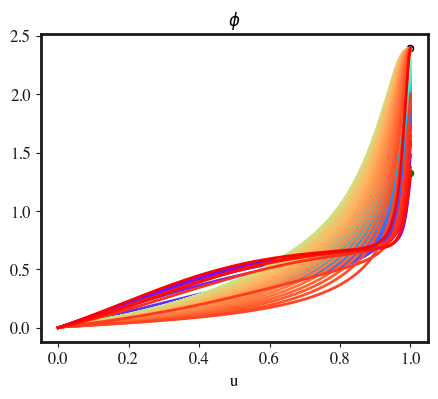

2.398090755355619


In [ ]:
u = torch.linspace(0,1,250)
var_names = ['Vs', 'Va', 'Vp', r'$\Sigma$', 'A', r'$\phi$']

fig= plt.figure(figsize=(5,4))

step = 1


RES = []
phi_solutions = []
step = step

j = 5  # phi solution
for i in range(len(c.Va_uh_all)):
    S = c.Sigma_uh_all[i].cpu().detach().numpy()*np.ones_like(u.cpu().detach().numpy())
    T = c.Va_uh_all[i].cpu().detach().numpy()*np.ones_like(u.cpu().detach().numpy())
    Z = c.Z[i].cpu().detach().numpy()*np.ones_like(u.cpu().detach().numpy())
    #print(c.solver.get_residuals(u,S,T))
    #res = c.solver.get_residuals(u,S,T,Z,best= False)
    sol = c.solver.get_solution(best = True)
    phi_sol = sol(u,S,T,Z)[j]
    #  RES.append(torch.stack(res).mean(dim = 0))
    phi_solutions.append(phi_sol.cpu().detach().numpy())

phi_first = phi_solutions[0][-1]
phi_last = phi_solutions[-1][-1]
phi_second_last = phi_solutions[-2][-1]

num_curves = len(c.Va_uh_all)
cmap = cm.get_cmap('rainbow', num_curves)
norm = mcolors.Normalize(vmin=0, vmax=num_curves - 1)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

for i in range(num_curves):
    #if i == step:# == 0:
    if i % step == 0:

        col = cmap(i / (num_curves - 1))
        
        y = u.cpu().detach().numpy()
        z = phi_solutions[i]

        plt.plot(y, z, color=col, linewidth=2, label=i)
        plt.title(var_names[j])
plt.scatter(1.0, phi_last, c = 'k', s=20)
plt.scatter(1.0, phi_second_last, c = 'green', s=20)
plt.xlabel('u')
# plt.legend(loc=(1.1,0.3))
plt.show()

print(phi_last)

In [ ]:
print('SB: phi first:', phi_first, 'phi last:', phi_last)


SB: phi first: 1.305643809461659 phi last: 2.398090755355619


In [ ]:
c.V

Second_Branch_V(
  (First_branch_V_NN): CustomNN(
    (layers): ModuleList(
      (0): Linear(in_features=1, out_features=32, bias=True)
      (1): SiLU()
      (2): Linear(in_features=32, out_features=32, bias=True)
      (3): SiLU()
      (4): Linear(in_features=32, out_features=32, bias=True)
      (5): SiLU()
      (6): Linear(in_features=32, out_features=32, bias=True)
      (7): SiLU()
    )
    (fc_out): Linear(in_features=32, out_features=1, bias=True)
  )
  (layers): ModuleList(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): SiLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): SiLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): SiLU()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): SiLU()
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): SiLU()
  )
  (fc_out): Linear(in_features=64, out_features=1, bias=True)
)

### Visualize the potential $V(\phi)$ at different scales (full profile, around true minimum, around FV)

phi_c 0.6900340158396734
hello [2.40745373] [-214.73026027]
V fv -3.473236533071779 DV fv -5.875343171545408e-05 DDV fv 8.93396100697101
0.02059372276016802
[2.39809076]


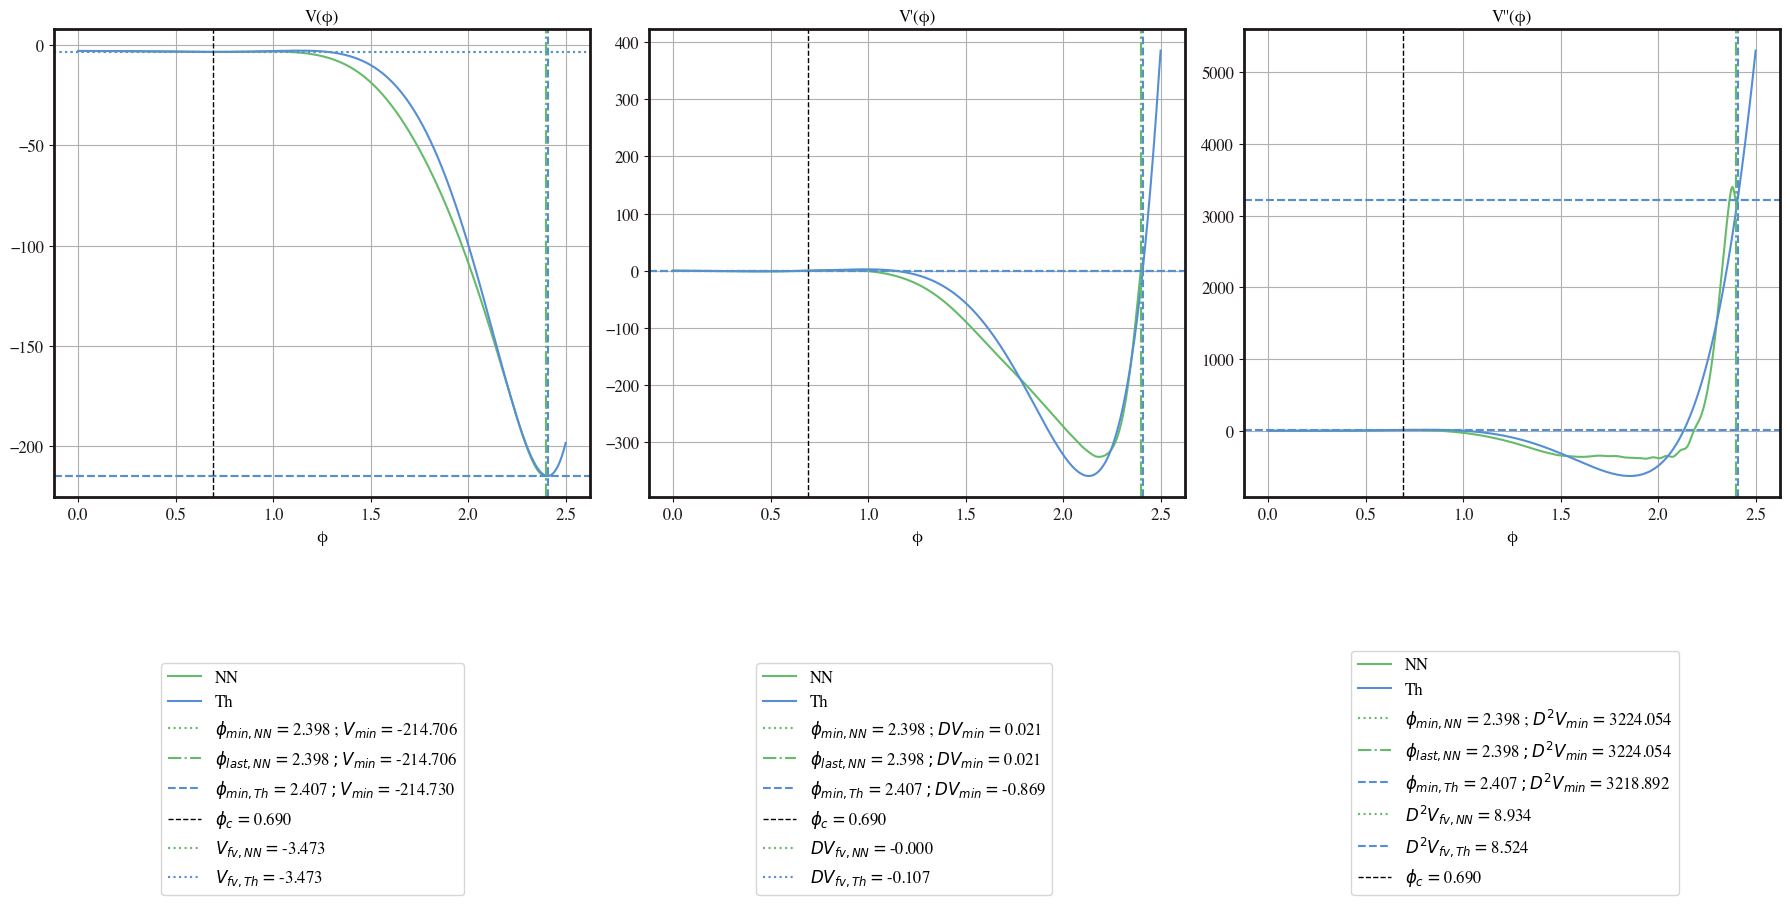

V(0) [-2.99978255] [-3.]
DV(0) 0.0009122916102541865 -0.0018759386209293183
DDV(0) -2.999567516137463 [-3.]


In [ ]:
phi = torch.linspace(0.0, phi_last, 2000, requires_grad=True).reshape(-1,1)

phi_th = np.linspace(0.0, 2.5, 2000).reshape(-1,1)
V_nn = c.solver.V(phi)

phi_c = c.V.phi_c

print('phi_c', phi_c)
# phi_c_idx = torch.argmin(torch.abs(phi - phi_c))

idx_min = np.argmin(V_nn.detach().numpy())
phi_min = phi[idx_min].detach().numpy()

V_th = V_or(phi_th, phim = 0.55)
idx_min_th = np.argmin(V_th)

print('hello', phi_th[idx_min_th], V_th[idx_min_th])

DV_th = np.gradient(V_th.reshape(-1,), phi_th.reshape(-1,))
DDV_th = DDV_or(phi_th, phim=0.55)

DV_nn = diff(V_nn.reshape(-1,1), phi, order=1).detach().numpy().reshape(-1,)
DDV_nn = diff(V_nn.reshape(-1,1), phi, order=2).detach().numpy().reshape(-1,)

V_fv_th = V_or(phi_c, phim=0.55)
DV_fv_th = DV_or(phi_c, phim=0.55)
DDV_fv_th = DDV_or(phi_c, phim=0.55)


phi_c_torch = torch.tensor([[phi_c+1e-10]], requires_grad=True)

V_c = c.solver.V(phi_c_torch)
DV_c = torch.autograd.grad(V_c, phi_c_torch, create_graph=True)[0]
DDV_c = torch.autograd.grad(DV_c, phi_c_torch)[0]

V_fv_nn = V_c.item()
DV_fv_nn = DV_c.item()
DDV_fv_nn = DDV_c.item()
print('V fv', V_fv_nn, 'DV fv',DV_fv_nn, 'DDV fv',DDV_fv_nn)



Vmin_th = V_th[idx_min_th]
DVmin_th = DV_th[idx_min_th]
DDVmin_th = DDV_th[idx_min_th][0]

Vmin_nn = V_nn.detach().numpy()[idx_min]
DVmin_nn = DV_nn[idx_min]
print(DVmin_nn)
DDVmin_nn = DDV_nn[idx_min]

phi_np = phi.detach().numpy().reshape(-1,)
Vnn_np = V_nn.detach().numpy().reshape(-1,)


fig, axes = plt.subplots(1, 3, figsize=(18, 15), sharex=True)

# --- 1) Potential ---
axes[0].plot(phi_np, Vnn_np, label='NN')
axes[0].plot(phi_th, V_th, label='Th')
axes[0].axvline(phi_min, linestyle='dotted', color='C0', label =r'$\phi_{min,NN}=$'+fr'{phi_min[0]:.3f}'+ r' ; $V_{min}=$'+rf'{Vmin_nn[0]:.3f}')
axes[0].axvline(phi_last, linestyle='dashdot', color='C0', label =r'$\phi_{last,NN}=$'+fr'{phi_last:.3f}'+ r' $; V_{min}=$'+rf'{Vnn_np[-1]:.3f}')
axes[0].axvline(phi_th[idx_min_th], linestyle='dashed', color='C1', label =r'$\phi_{min,Th}=$'+fr'{phi_th[idx_min_th][0]:.3f}'+ r' $; V_{min}=$'+rf'{Vmin_th[0]:.3f}')
axes[0].axhline(Vmin_nn, linestyle='dashed', color='C0')
axes[0].axhline(Vmin_th, linestyle='dashed', color='C1')
axes[0].axvline(phi_c, linestyle='dashed', color='k', linewidth=1, label =r'$\phi_c=$'+fr'{phi_c:.3f}')
axes[0].axhline(V_fv_nn, linestyle='dotted', color='C0', label =r'$V_{fv,NN}=$'+fr'{V_fv_nn:.3f}')
axes[0].axhline(V_fv_th, linestyle='dotted', color='C1', label =r'$V_{fv,Th}=$'+fr'{V_fv_th:.3f}')
# axes[0].set_ylim(top=0)
axes[0].set_title('V(φ)')
axes[0].legend(loc=(0.2,-0.85))
axes[0].grid()
print(phi_min)
# --- 2) First derivative ---
axes[1].plot(phi_np, DV_nn, label='NN')
axes[1].plot(phi_th, DV_th, label='Th')
axes[1].axvline(phi_min, linestyle='dotted', color='C0', label =r'$\phi_{min,NN}=$'+fr'{phi_min[0]:.3f}'+ r' ; $DV_{min}=$'+rf'{DVmin_nn:.3f}')
axes[1].axvline(phi_last, linestyle='dashdot', color='C0', label =r'$\phi_{last,NN}=$'+fr'{phi_last:.3f}'+ r' $; DV_{min}=$'+rf'{DV_nn[-1]:.3f}')
axes[1].axvline(phi_th[idx_min_th], linestyle='dashed', color='C1', label =r'$\phi_{min,Th}=$'+fr'{phi_th[idx_min_th][0]:.3f}'+ r' $; DV_{min}=$'+rf'{DVmin_th:.3f}')
axes[1].axhline(DVmin_nn, linestyle='dashed', color='C0')
axes[1].axhline(DVmin_th, linestyle='dashed', color='C1')
axes[1].axvline(phi_c, linestyle='dashed', color='k', linewidth=1, label =r'$\phi_c=$'+fr'{phi_c:.3f}')
axes[1].axhline(DV_fv_nn, linestyle='dotted', color='C0', label =r'$DV_{fv,NN}=$'+fr'{DV_fv_nn:.3f}')
axes[1].axhline(DV_fv_th, linestyle='dotted', color='C1', label =r'$DV_{fv,Th}=$'+fr'{DV_fv_th:.3f}')
# axes[1].set_ylim(top=50)
axes[1].set_title("V'(φ)")
axes[1].legend(loc=(0.2,-0.85))
axes[1].grid()

# --- 3) Second derivative ---
axes[2].plot(phi_np, DDV_nn, label='NN')
axes[2].plot(phi_th, DDV_th, label='Th')
axes[2].axvline(phi_min, linestyle='dotted', color='C0', label =r'$\phi_{min,NN}=$'+fr'{phi_min[0]:.3f}'+ r' ; $D^2V_{min}=$'+rf'{DDVmin_nn:.3f}')
axes[2].axvline(phi_last, linestyle='dashdot', color='C0', label =r'$\phi_{last,NN}=$'+fr'{phi_last:.3f}'+ r' $; D^2V_{min}=$'+rf'{DDV_nn[-1]:.3f}')
axes[2].axhline(DDVmin_nn, linestyle='dashed', color='C0')
axes[2].axhline(DDVmin_th, linestyle='dashed', color='C1')
axes[2].axvline(phi_th[idx_min_th], linestyle='dashed', color='C1', label =r'$\phi_{min,Th}=$'+fr'{phi_th[idx_min_th][0]:.3f}'+ r' $; D^2V_{min}=$'+rf'{DDVmin_th:.3f}')
axes[2].axhline(DDV_fv_nn, linestyle='dotted', color='C0', label =r'$D^2V_{fv,NN}=$'+fr'{DDV_fv_nn:.3f}', )
axes[2].axhline(DDV_fv_th, linestyle='dashed', color='C1', label =r'$D^2V_{fv,Th}=$'+fr'{DDV_fv_th:.3f}')
axes[2].axvline(phi_c, linestyle='dashed', color='k', linewidth=1, label =r'$\phi_c=$'+fr'{phi_c:.3f}')
# axes[2].set_yscale('log')
# axes[2].set_ylim(top =4000, bottom =1000)
# axes[2].set_xlim(left=2, right=2.6)

axes[2].set_title("V''(φ)")
axes[2].legend(loc=(0.2,-0.85))
axes[2].grid()

for ax in axes:
    ax.set_xlabel('φ')

plt.tight_layout()
plt.show()

print('V(0)', V_nn.detach().numpy()[0], V_th[0])
print('DV(0)', DV_nn[0], DV_th[0])
print('DDV(0)', DDV_nn[0], DDV_th[0])


[2.39809076]


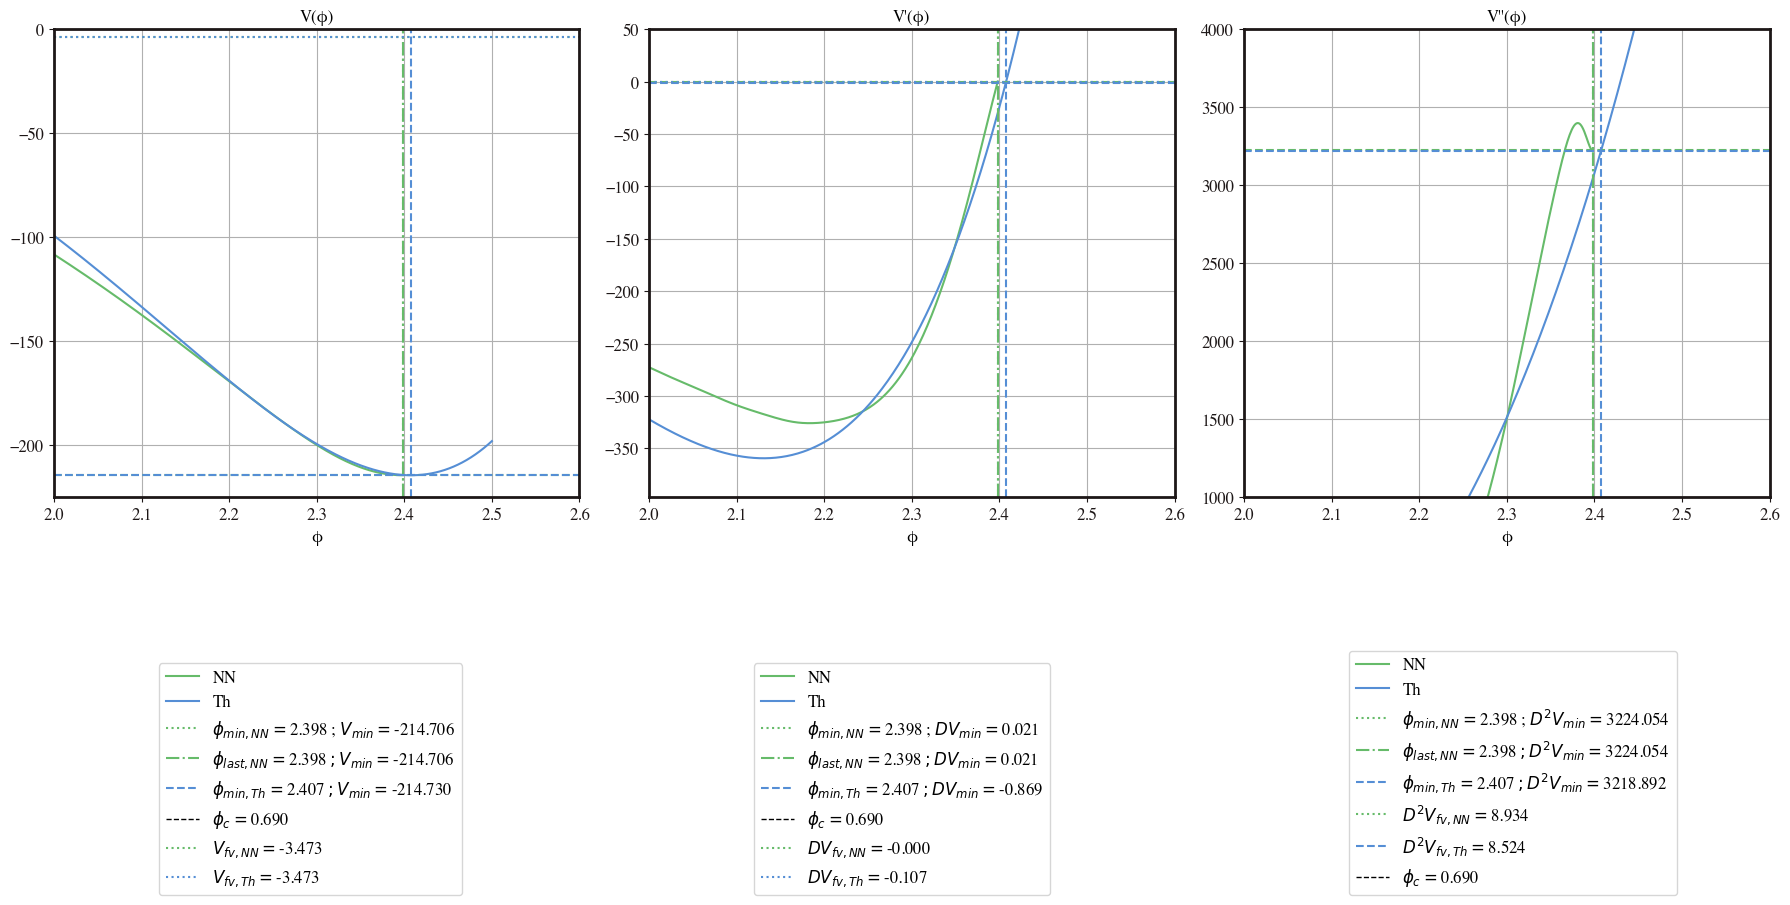

V(0) [-2.99978255] [-3.]
DV(0) 0.0009122916102541865 -0.0018759386209293183
DDV(0) -2.999567516137463 [-3.]


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 15), sharex=True)

# --- 1) Potential ---
axes[0].plot(phi_np, Vnn_np, label='NN')
axes[0].plot(phi_th, V_th, label='Th')
axes[0].axvline(phi_min, linestyle='dotted', color='C0', label =r'$\phi_{min,NN}=$'+fr'{phi_min[0]:.3f}'+ r' ; $V_{min}=$'+rf'{Vmin_nn[0]:.3f}')
axes[0].axvline(phi_last, linestyle='dashdot', color='C0', label =r'$\phi_{last,NN}=$'+fr'{phi_last:.3f}'+ r' $; V_{min}=$'+rf'{Vnn_np[-1]:.3f}')
axes[0].axvline(phi_th[idx_min_th], linestyle='dashed', color='C1', label =r'$\phi_{min,Th}=$'+fr'{phi_th[idx_min_th][0]:.3f}'+ r' $; V_{min}=$'+rf'{Vmin_th[0]:.3f}')
axes[0].axhline(Vmin_nn, linestyle='dashed', color='C0')
axes[0].axhline(Vmin_th, linestyle='dashed', color='C1')
axes[0].axvline(phi_c, linestyle='dashed', color='k', linewidth=1, label =r'$\phi_c=$'+fr'{phi_c:.3f}')
axes[0].axhline(V_fv_nn, linestyle='dotted', color='C0', label =r'$V_{fv,NN}=$'+fr'{V_fv_nn:.3f}')
axes[0].axhline(V_fv_th, linestyle='dotted', color='C1', label =r'$V_{fv,Th}=$'+fr'{V_fv_th:.3f}')
axes[0].set_ylim(top=0)
axes[0].set_title('V(φ)')
axes[0].legend(loc=(0.2,-0.85))
axes[0].grid()
print(phi_min)
# --- 2) First derivative ---
axes[1].plot(phi_np, DV_nn, label='NN')
axes[1].plot(phi_th, DV_th, label='Th')
axes[1].axvline(phi_min, linestyle='dotted', color='C0', label =r'$\phi_{min,NN}=$'+fr'{phi_min[0]:.3f}'+ r' ; $DV_{min}=$'+rf'{DVmin_nn:.3f}')
axes[1].axvline(phi_last, linestyle='dashdot', color='C0', label =r'$\phi_{last,NN}=$'+fr'{phi_last:.3f}'+ r' $; DV_{min}=$'+rf'{DV_nn[-1]:.3f}')
axes[1].axvline(phi_th[idx_min_th], linestyle='dashed', color='C1', label =r'$\phi_{min,Th}=$'+fr'{phi_th[idx_min_th][0]:.3f}'+ r' $; DV_{min}=$'+rf'{DVmin_th:.3f}')
axes[1].axhline(DVmin_nn, linestyle='dashed', color='C0')
axes[1].axhline(DVmin_th, linestyle='dashed', color='C1')
axes[1].axvline(phi_c, linestyle='dashed', color='k', linewidth=1, label =r'$\phi_c=$'+fr'{phi_c:.3f}')
axes[1].axhline(DV_fv_nn, linestyle='dotted', color='C0', label =r'$DV_{fv,NN}=$'+fr'{DV_fv_nn:.3f}')
axes[1].axhline(DV_fv_th, linestyle='dotted', color='C1', label =r'$DV_{fv,Th}=$'+fr'{DV_fv_th:.3f}')
axes[1].set_ylim(top=50)
axes[1].set_title("V'(φ)")
axes[1].legend(loc=(0.2,-0.85))
axes[1].grid()

# --- 3) Second derivative ---
axes[2].plot(phi_np, DDV_nn, label='NN')
axes[2].plot(phi_th, DDV_th, label='Th')
axes[2].axvline(phi_min, linestyle='dotted', color='C0', label =r'$\phi_{min,NN}=$'+fr'{phi_min[0]:.3f}'+ r' ; $D^2V_{min}=$'+rf'{DDVmin_nn:.3f}')
axes[2].axvline(phi_last, linestyle='dashdot', color='C0', label =r'$\phi_{last,NN}=$'+fr'{phi_last:.3f}'+ r' $; D^2V_{min}=$'+rf'{DDV_nn[-1]:.3f}')
axes[2].axhline(DDVmin_nn, linestyle='dashed', color='C0')
axes[2].axhline(DDVmin_th, linestyle='dashed', color='C1')
axes[2].axvline(phi_th[idx_min_th], linestyle='dashed', color='C1', label =r'$\phi_{min,Th}=$'+fr'{phi_th[idx_min_th][0]:.3f}'+ r' $; D^2V_{min}=$'+rf'{DDVmin_th:.3f}')
axes[2].axhline(DDV_fv_nn, linestyle='dotted', color='C0', label =r'$D^2V_{fv,NN}=$'+fr'{DDV_fv_nn:.3f}', )
axes[2].axhline(DDV_fv_th, linestyle='dashed', color='C1', label =r'$D^2V_{fv,Th}=$'+fr'{DDV_fv_th:.3f}')
axes[2].axvline(phi_c, linestyle='dashed', color='k', linewidth=1, label =r'$\phi_c=$'+fr'{phi_c:.3f}')
# axes[2].set_yscale('log')
axes[2].set_ylim(top =4000, bottom =1000)
axes[2].set_xlim(left=2, right=2.6)

axes[2].set_title("V''(φ)")
axes[2].legend(loc=(0.2,-0.85))
axes[2].grid()

for ax in axes:
    ax.set_xlabel('φ')

plt.tight_layout()
plt.show()

print('V(0)', V_nn.detach().numpy()[0], V_th[0])
print('DV(0)', DV_nn[0], DV_th[0])
print('DDV(0)', DDV_nn[0], DDV_th[0])

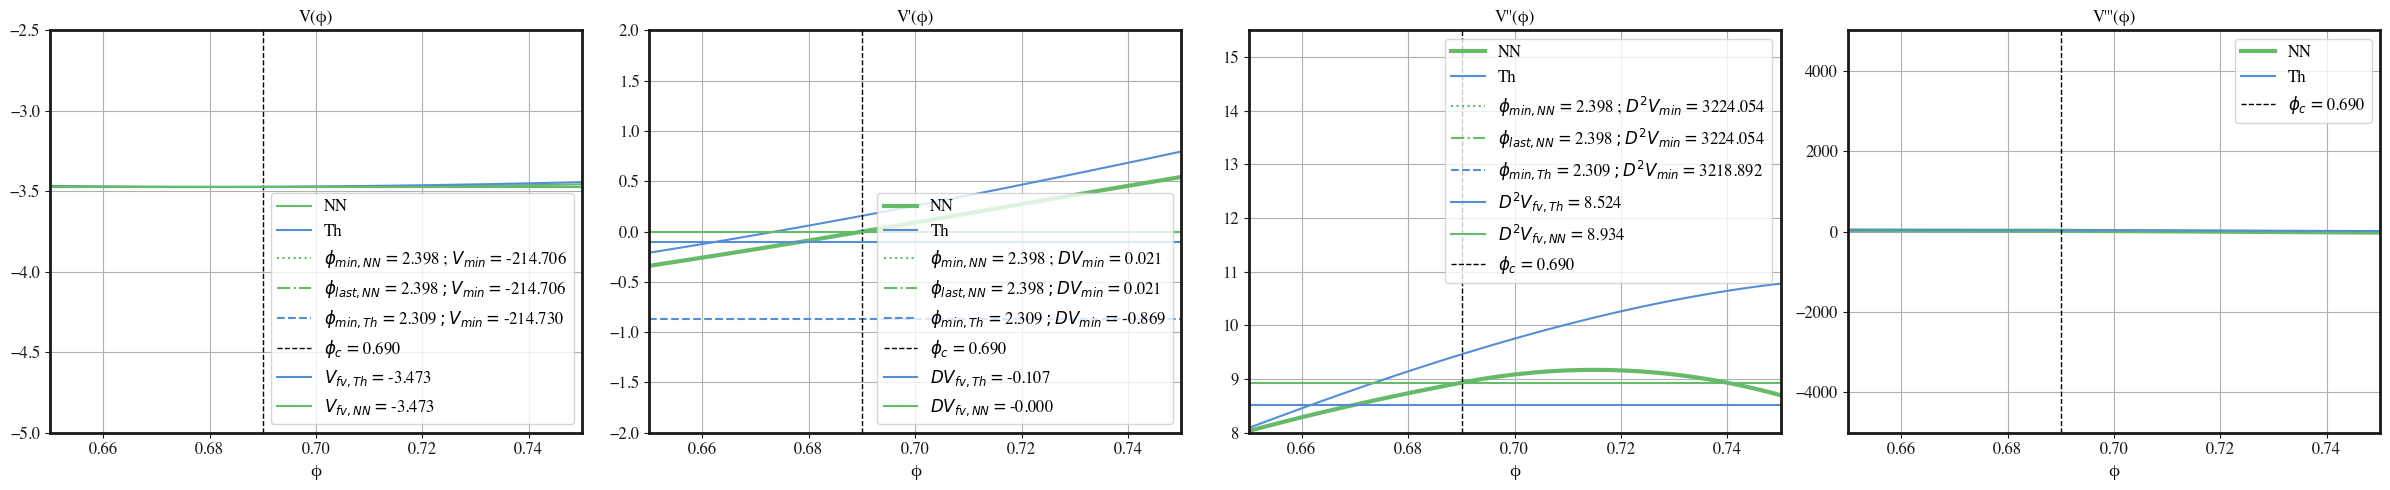

In [ ]:
# Calculate third derivatives
DDDV_th = np.gradient(DDV_th.reshape(-1,), phi.detach().numpy().reshape(-1,))
DDDV_nn = diff(V_nn.reshape(-1,1), phi, order=3).detach().numpy().reshape(-1,)

# Add a 4th plot for the third derivative
fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharex=True)

phi_np = phi.detach().numpy().reshape(-1,)
Vnn_np = V_nn.detach().numpy().reshape(-1,)

# --- 1) Potential ---
axes[0].plot(phi_np, Vnn_np, label='NN')
axes[0].plot(phi_np, V_th, label='Th')
axes[0].axvline(phi_min, linestyle='dotted', color='C0', label =r'$\phi_{min,NN}=$'+fr'{phi_min[0]:.3f}'+ r' ; $V_{min}=$'+rf'{Vmin_nn[0]:.3f}')
axes[0].axvline(phi_last, linestyle='dashdot', color='C0', label =r'$\phi_{last,NN}=$'+fr'{phi_last:.3f}'+ r' $; V_{min}=$'+rf'{Vnn_np[-1]:.3f}')
axes[0].axvline(phi_np[idx_min_th], linestyle='dashed', color='C1', label =r'$\phi_{min,Th}=$'+fr'{phi_np[idx_min_th]:.3f}'+ r' $; V_{min}=$'+rf'{Vmin_th[0]:.3f}')
axes[0].axhline(Vmin_th, linestyle='dashed', color='C1')
axes[0].axvline(phi_c, linestyle='dashed', color='k', linewidth=1, label =r'$\phi_c=$'+fr'{phi_c:.3f}')
axes[0].axhline(V_fv_th, linestyle='solid', color='C1', label =r'$V_{fv,Th}=$'+fr'{V_fv_th:.3f}')
axes[0].axhline(V_fv_nn, linestyle='solid', color='C0', label =r'$V_{fv,NN}=$'+fr'{V_fv_nn:.3f}')
axes[0].set_ylim(top=-2.5, bottom = -5)
axes[0].set_title('V(φ)')
axes[0].legend()
axes[0].grid()

# --- 2) First derivative ---
axes[1].plot(phi_np, DV_nn, label='NN', linewidth=3)
axes[1].plot(phi_np, DV_th, label='Th')
axes[1].axvline(phi_min, linestyle='dotted', color='C0', label =r'$\phi_{min,NN}=$'+fr'{phi_min[0]:.3f}'+ r' ; $DV_{min}=$'+rf'{DVmin_nn:.3f}')
axes[1].axvline(phi_last, linestyle='dashdot', color='C0', label =r'$\phi_{last,NN}=$'+fr'{phi_last:.3f}'+ r' $; DV_{min}=$'+rf'{DV_nn[-1]:.3f}')
axes[1].axvline(phi_np[idx_min_th], linestyle='dashed', color='C1', label =r'$\phi_{min,Th}=$'+fr'{phi_np[idx_min_th]:.3f}'+ r' $; DV_{min}=$'+rf'{DVmin_th:.3f}')
axes[1].axhline(DVmin_th, linestyle='dashed', color='C1')
axes[1].axvline(phi_c, linestyle='dashed', color='k', linewidth=1, label =r'$\phi_c=$'+fr'{phi_c:.3f}')
axes[1].axhline(DV_fv_th, linestyle='solid', color='C1', label =r'$DV_{fv,Th}=$'+fr'{DV_fv_th:.3f}')
axes[1].axhline(DV_fv_nn, linestyle='solid', color='C0', label =r'$DV_{fv,NN}=$'+fr'{DV_fv_nn:.3f}')
axes[1].set_ylim(top=2, bottom = -2)
axes[1].legend()

axes[1].set_title("V'(φ)")
axes[1].grid()

# --- 3) Second derivative ---
axes[2].plot(phi_np, DDV_nn, label='NN', linewidth=3)
axes[2].plot(phi_np, DDV_th, label='Th')
axes[2].axvline(phi_min, linestyle='dotted', color='C0', label =r'$\phi_{min,NN}=$'+fr'{phi_min[0]:.3f}'+ r' ; $D^2V_{min}=$'+rf'{DDVmin_nn:.3f}')
axes[2].axvline(phi_last, linestyle='dashdot', color='C0', label =r'$\phi_{last,NN}=$'+fr'{phi_last:.3f}'+ r' $; D^2V_{min}=$'+rf'{DDV_nn[-1]:.3f}')
axes[2].axhline(DDVmin_th, linestyle='dashed', color='C1')
axes[2].axvline(phi_np[idx_min_th], linestyle='dashed', color='C1', label =r'$\phi_{min,Th}=$'+fr'{phi_np[idx_min_th]:.3f}'+ r' $; D^2V_{min}=$'+rf'{DDVmin_th:.3f}')
axes[2].axhline(DDV_fv_th, linestyle='solid', color='C1', label =r'$D^2V_{fv,Th}=$'+fr'{DDV_fv_th:.3f}')
axes[2].axhline(DDV_fv_nn, linestyle='solid', color='C0', label =r'$D^2V_{fv,NN}=$'+fr'{DDV_fv_nn:.3f}')
axes[2].axvline(phi_c, linestyle='dashed', color='k', linewidth=1, label =r'$\phi_c=$'+fr'{phi_c:.3f}')
axes[2].set_ylim(top = 15.5, bottom = 8)
axes[2].set_xlim(left = 0.65, right = 0.75)
axes[2].set_title("V''(φ)")
axes[2].legend()
axes[2].grid()

# --- 4) Third derivative ---
axes[3].plot(phi_np, DDDV_nn, label='NN', linewidth=3)
axes[3].plot(phi_np, DDDV_th, label='Th')
axes[3].set_title("V'''(φ)")
axes[3].grid()
axes[3].set_xlim(left = 0.65, right = 0.75)
axes[3].axvline(phi_c, linestyle='dashed', color='k', linewidth=1, label =r'$\phi_c=$'+fr'{phi_c:.3f}')

axes[3].set_ylim(top =5000, bottom = -5000)


axes[3].legend()

for ax in axes:
    ax.set_xlabel('φ')

plt.tight_layout()
plt.show()


In [ ]:
c.V.derivatives

tensor([[-3.4732e+00],
        [-5.8754e-05],
        [ 8.9340e+00],
        [ 1.8979e+01]])

V2_renorm.shape torch.Size([1000, 1])
sigmoid1.shape torch.Size([1000, 1])
sigmoid2.shape torch.Size([1000, 1])
Vtot.shape torch.Size([1000, 1])
phi0.shape (1000,)
V1.shape (1000, 1)


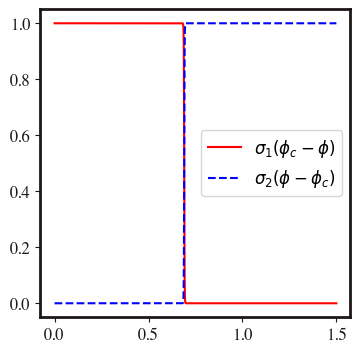

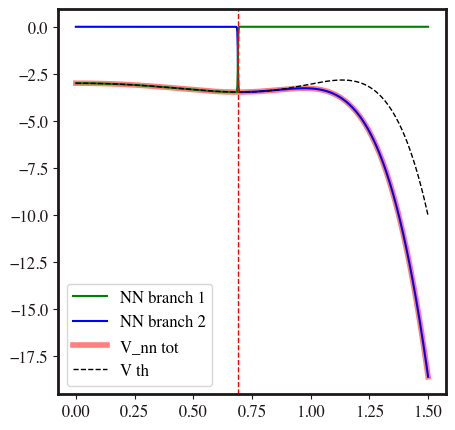

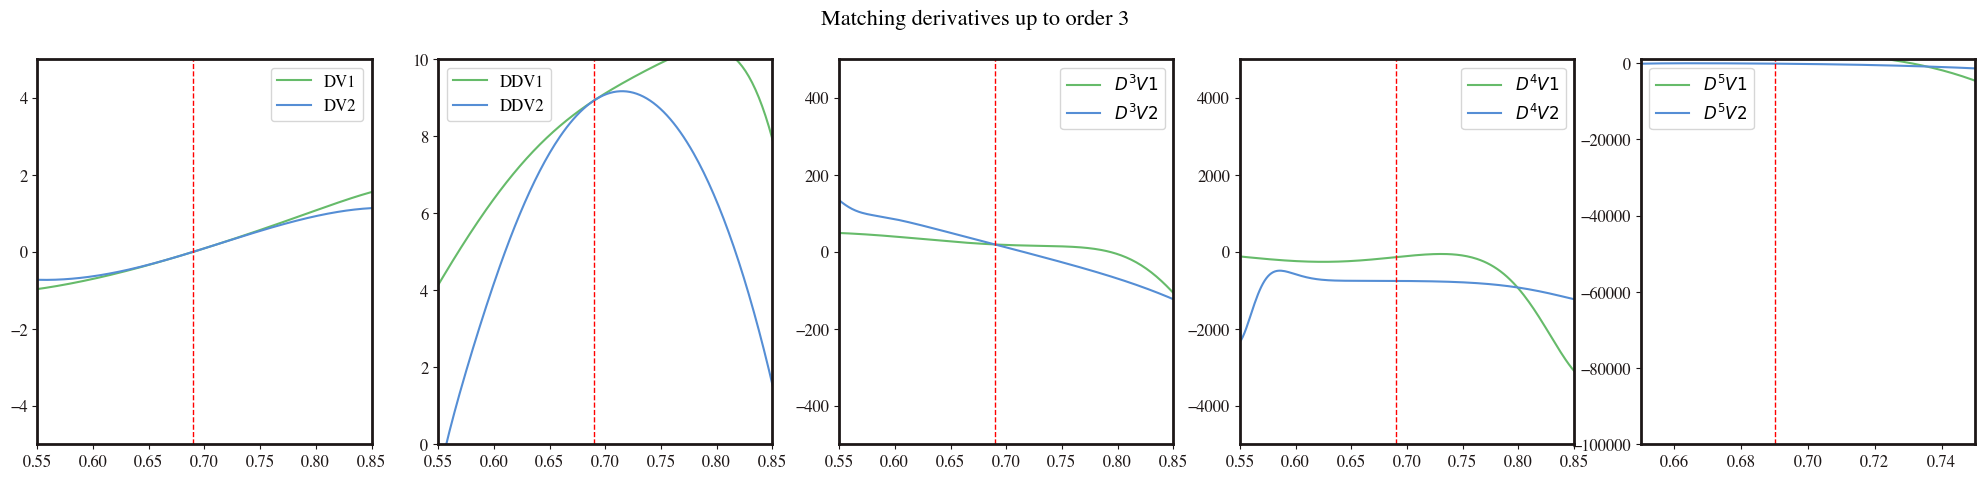

In [ ]:
inputx = torch.linspace(0.0,1.5,1000).reshape(-1,1)
x = inputx
for i, layer in enumerate(c.V.layers):
    x = layer(x)
    if i == 0:
        x = x * torch.exp(- ((x - c.V.mu) ** 2) / (2 * (c.V.sigma**2))) 
V2 = c.V.fc_out(x)

V2_renorm = V_matching_derivatives(V2 = V2, phi = inputx, phi_c=c.V.phi_c, derivatives = c.V.derivatives)
print('V2_renorm.shape', V2_renorm.shape)
# print('V2_renorm', V2_renorm.detach().numpy())

a = 1000
sigmoid1 = torch.sigmoid( - a*(inputx - c.V.phi_c))
sigmoid2 = torch.sigmoid( a*(inputx - c.V.phi_c))

print('sigmoid1.shape', sigmoid1.shape)

print('sigmoid2.shape', sigmoid2.shape)

V1 = c.V.First_branch_V_NN(inputx).reshape(-1,1)

Vtot = V1 * sigmoid1 + V2_renorm * sigmoid2
print('Vtot.shape', Vtot.shape)
#print(V1.detach().numpy())
phi0 =  np.concatenate(inputx.detach().numpy())
print('phi0.shape', phi0.shape)
print('V1.shape', V1.detach().numpy().shape)

DV1 = np.gradient(V1.reshape(-1,).detach().numpy(), phi0)
DV2 = np.gradient(np.concatenate(V2_renorm.detach().numpy()), phi0)

DDV1 = np.gradient(DV1, phi0)
DDV2 = np.gradient(DV2, phi0)

D3V1 = np.gradient(DDV1, phi0)
D3V2 = np.gradient(DDV2, phi0)

D4V1 = np.gradient(D3V1, phi0)
D4V2 = np.gradient(D3V2, phi0)

D5V1 = np.gradient(D4V1, phi0)
D5V2 = np.gradient(D4V2, phi0)

phi_1 = torch.linspace(0,1,1000).reshape(-1,1).detach().numpy()
V1 = c.V.First_branch_V_NN(inputx)
V_th_1 = V_or(phi_1, phim=0.55)

plt.plot(inputx.detach().numpy(), sigmoid1, label=r'$\sigma_1(\phi_c-\phi)$', color='red')
plt.plot(inputx.detach().numpy(), sigmoid2, label=r'$\sigma_2(\phi-\phi_c)$', linestyle = 'dashed', zorder=2, color='blue')
plt.legend()
plt.show()


fig = plt.figure(figsize = (5,5))

plt.plot(inputx.detach().numpy(), sigmoid1 * V1.detach().numpy(), label = 'NN branch 1', zorder=2, color = 'green')
plt.plot(inputx.detach().numpy(), sigmoid2 * V2_renorm.detach().numpy(), label = 'NN branch 2', zorder=1, color='blue')
plt.plot(inputx.detach().numpy(), Vtot.detach().numpy(), label = 'V_nn tot', zorder=0, linewidth=4, linestyle = 'solid', color='red', alpha=0.5)
plt.plot(inputx.detach().numpy(), V_or(inputx.detach().numpy(), phim=0.55) , linestyle = 'dashed', linewidth=1, color = 'k', label = 'V th')
#plt.axvline(phi_1[np.argmin(V_th_1)], color = 'k', linestyle = 'dashed', linewidth=1)
plt.axvline(c.V.phi_c, color = 'red', linestyle = 'dashed', linewidth=1)
# plt.xlim(right=1.5,left = 0)
# plt.ylim(top=5, bottom=-10)
plt.legend()
plt.show()

fig,ax  = plt.subplots(1,5, figsize = (25,5))

ax[0].plot(phi0, DV1, label = 'DV1')
ax[0].plot(phi0, DV2,label = 'DV2')
ax[0].axvline(c.V.phi_c, color = 'red', linestyle = 'dashed', linewidth=1)
ax[1].plot(phi0, DDV1, label = 'DDV1')
ax[1].plot(phi0, DDV2, label = 'DDV2')
ax[1].axvline(c.V.phi_c, color = 'red', linestyle = 'dashed', linewidth=1)
ax[2].plot(phi0, D3V1, label = r'$D^3 V1$')
ax[2].plot(phi0, D3V2, label = r'$D^3 V2$')
ax[2].axvline(c.V.phi_c, color = 'red', linestyle = 'dashed', linewidth=1)
ax[3].plot(phi0, D4V1, label = r'$D^4 V1$')
ax[3].plot(phi0, D4V2, label = r'$D^4 V2$')
ax[3].axvline(c.V.phi_c, color = 'red', linestyle = 'dashed', linewidth=1)

ax[4].plot(phi0, D5V1, label = r'$D^5 V1$')
ax[4].plot(phi0, D5V2, label = r'$D^5 V2$')
ax[4].axvline(c.V.phi_c, color = 'red', linestyle = 'dashed', linewidth=1)

for i in range(5):
    ax[i].set_xlim(left=0.55, right=0.85)
    
ax[0].set_ylim(top=5, bottom=-5)
ax[1].set_ylim(top=10, bottom=-0)

ax[2].set_ylim(top=500, bottom=-500)
ax[3].set_ylim(top=5000, bottom=-5000)

ax[4].set_ylim(top=1000, bottom=-100000)
ax[4].set_xlim(left=0.65, right=0.75)

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()
ax[4].legend()
plt.suptitle(f'Matching derivatives up to order {order}')

plt.show()

In [ ]:
phi = torch.linspace(0.0, phi_last, 2000, requires_grad=True).reshape(-1,1)

phi_th = np.linspace(0.0, 2.8, 2000).reshape(-1,1)
V_nn = c.solver.V(phi)

phi_c = c.V.phi_c

phi_mock_th = np.linspace(0,1.0, 1000)
phi_fv_th = phi_mock_th[np.argmin(V_or(phi_mock_th, phim=0.55))]

print('phi_c', phi_c)
# phi_c_idx = torch.argmin(torch.abs(phi - phi_c))

idx_min = np.argmin(V_nn.detach().numpy())
phi_min = phi[idx_min].detach().numpy()

V_th = V_or(phi_th, phim = 0.55)
idx_min_th = np.argmin(V_th)


DV_th = np.gradient(V_th.reshape(-1,), phi_th.reshape(-1,))
DDV_th = DDV_or(phi_th, phim=0.55)

DV_nn = diff(V_nn.reshape(-1,1), phi, order=1).detach().numpy().reshape(-1,)
DDV_nn = diff(V_nn.reshape(-1,1), phi, order=2).detach().numpy().reshape(-1,)

V_fv_th = V_or(phi_c, phim=0.55)
DV_fv_th = DV_or(phi_c, phim=0.55)
DDV_fv_th = DDV_or(phi_c, phim=0.55)

phi_c_torch = torch.tensor([[phi_c+1e-10]], requires_grad=True)

V_c = c.solver.V(phi_c_torch)
DV_c = torch.autograd.grad(V_c, phi_c_torch, create_graph=True)[0]
DDV_c = torch.autograd.grad(DV_c, phi_c_torch)[0]

V_fv_nn = V_c.item()
DV_fv_nn = DV_c.item()
DDV_fv_nn = DDV_c.item()
print('V fv', V_fv_nn, 'DV fv',DV_fv_nn, 'DDV fv',DDV_fv_nn)



Vmin_th = V_th[idx_min_th]
DVmin_th = DV_th[idx_min_th]
DDVmin_th = DDV_th[idx_min_th][0]

Vmin_nn = V_nn.detach().numpy()[idx_min]
DVmin_nn = DV_nn[idx_min]
DDVmin_nn = DDV_nn[idx_min]

phi_np = phi.detach().numpy().reshape(-1,)
Vnn_np = V_nn.detach().numpy().reshape(-1,)


phi_first_th = 3.64856850814877464728169798036105930805206298828 / 2   # from numerical solution of the theoretical potential


phi_c 0.6900340158396734
V fv -3.473236533071779 DV fv -5.875343171545408e-05 DDV fv 8.93396100697101


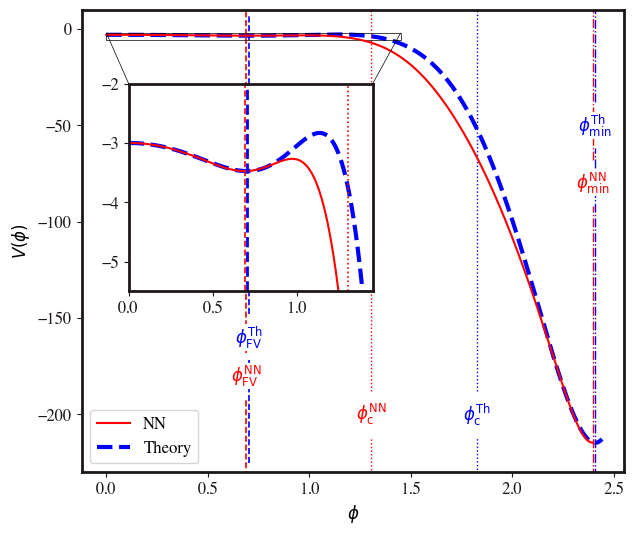

phi FV Th: 0.7027027027027027
phi FV NN: 0.6900340158396734
phi c Th: 1.8242842540743873
phi c NN: 1.305643809461659


In [ ]:
# -----------------------
# Helper function
# -----------------------

def split_vline_with_label(
    ax,
    x,
    y_text,
    label,
    color='k',
    linestyle='--',
    linewidth=1.2,
    fontsize=12,
    gap=12
):
    """
    Draw a vertical line interrupted by a centered label.
    """

    y_bottom, y_top = ax.get_ylim()

    # lower segment
    ax.plot(
        [x, x],
        [y_bottom, y_text - gap],
        color=color,
        linestyle=linestyle,
        linewidth=linewidth,
        zorder=1
    )

    # upper segment
    ax.plot(
        [x, x],
        [y_text + gap, y_top],
        color=color,
        linestyle=linestyle,
        linewidth=linewidth,
        zorder=1
    )

    # centered label
    ax.text(
        x,
        y_text,
        label,
        color=color,
        fontsize=fontsize,
        ha='center',
        va='center',
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            pad=0.2
        ),
        zorder=5
    )


# -----------------------
# Replace ALL axvline + text blocks with this
# -----------------------


from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(7, 6))

# Main plot
ax.plot(phi_np, Vnn_np, label='NN', color='red')
ax.plot(
    phi_th[:idx_min_th+25],
    V_th[:idx_min_th+25],
    '--',
    color='blue',
    linewidth=3,
    zorder=1,
    label='Theory'
)

# -----------------------
# TEXT LABELS INSIDE PLOT
# -----------------------

y_label_pos = -200

# phi FV
split_vline_with_label(
    ax,
    phi_fv_th,
    y_label_pos+40,
    r'$\phi_\mathrm{FV}^\mathrm{Th}$',
    color='blue',
    linestyle='dashed',
    linewidth=1.2
)

split_vline_with_label(
    ax,
    c.V.phi_c,
    y_label_pos-20+40,
    r'$\phi_\mathrm{FV}^\mathrm{NN}$',
    color='red',
    linestyle='dashed',
    linewidth=1.2
)

# phi c

split_vline_with_label(
    ax,
    phi_first_th,
    y_label_pos,
    r'$\phi_\mathrm{c}^\mathrm{Th}$',
    color='blue',
    linestyle='dotted',
    linewidth=1
)

split_vline_with_label(
    ax,
    phi_first,
    y_label_pos,
    r'$\phi_\mathrm{c}^\mathrm{NN}$',
    color='red',
    linestyle='dotted',
    linewidth=1
)


# phi min
split_vline_with_label(
    ax,
    phi_th[idx_min_th],
    -50,
    r'$\phi_\mathrm{min}^\mathrm{Th}$',
    color='blue',
    linestyle='dashdot',
    linewidth=1
)

split_vline_with_label(
    ax,
    phi_last,
    -50-30,
    r'$\phi_\mathrm{min}^\mathrm{NN}$',
    color='red',
    linestyle='dashdot',
    linewidth=1
)

ax.set_xlabel(r'$\phi$')
ax.set_ylabel(r'$V(\phi)$')


# Keep only NN/Theory in legend
ax.legend(loc='best')

# -----------------------
# 🔍 Inset
# -----------------------

ax_inset = inset_axes(
    ax,
    width="90%",
    height="90%",
    bbox_to_anchor=(0.01, 0.3, 0.5, 0.5),
    bbox_transform=ax.transAxes,
    loc='lower left',
    borderpad=2.5
)

# Zoom region
x1, x2 = 0, 1.45
y1, y2 = -5.5, -2

ax_inset.set_xlim(x1, x2)
ax_inset.set_ylim(y1, y2)

# Plot inset
ax_inset.plot(phi_np, Vnn_np, color='red', zorder=2)

ax_inset.plot(
    phi_th[:idx_min_th],
    V_th[:idx_min_th],
    linestyle='dashed',
    linewidth=3,
    color='blue',
    zorder=1
)

# inset vertical lines
ax_inset.axvline(phi_fv_th, color='blue', linestyle='dashed', linewidth=2)
ax_inset.axvline(c.V.phi_c, color='red', linestyle='dashed', linewidth=1.2)
ax_inset.axvline(phi_first, color='red', linestyle='dotted', linewidth=1.2)

ax_inset.tick_params(axis='both', which='major', labelsize=12)

# Rectangle + connectors
mark_inset(
    ax,
    ax_inset,
    loc1=2,
    loc2=1,
    fc="none",
    ec="black",
    lw=0.5
)

# Final styling
ax.set_xlim(right=2.55)
ax.set_ylim(bottom=min(V_th)[0]-15, top=10)

# fig.savefig(...)

plt.show()

# fig.savefig(f'{plots_dir}/V_recovered_fixed_from_end_epochs_{c.solver.global_epoch}_all_vlines.pdf', bbox_inches="tight")
# fig.savefig(f'{plots_dir}/V_recovered_fixed_from_end_epochs_{approx_epoch_num}_all_vlines.pdf', bbox_inches="tight")


print('phi FV Th:', phi_fv_th)
print('phi FV NN:', c.V.phi_c)

print('phi c Th:', phi_first_th)
print('phi c NN:', phi_first)



phi FV NN is smaller than phi FV Th, using phi FV Th for error calculation
Using common range for error calculation
MRE joint: 15.942 %
Max RE joint: 96.130 %


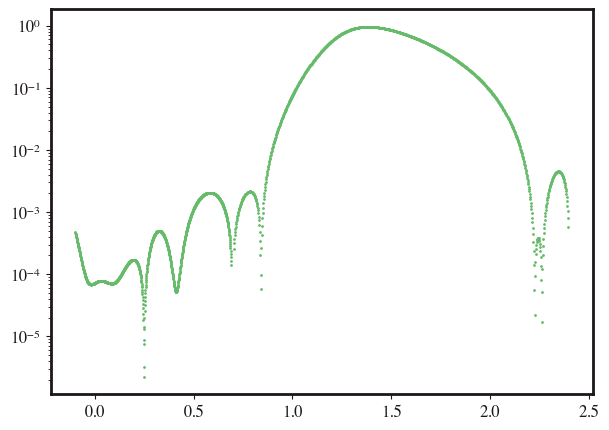

MRE FB: 0.05293935739883198 % RMS: 0.08316077079326939 %
max RE FB: 0.20558240121430182 %

MRE SB: 31.830344207040728 % RMS: 46.38514175571655 %
max RE SB: 96.12966145176554 %


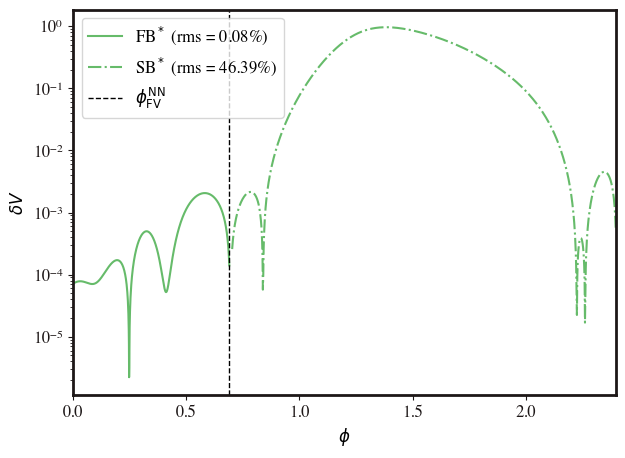

In [ ]:
n_points = 1000



if c.V.phi_c > phi_fv_th:
    print('phi FV NN is greater than phi FV Th, using phi FV Th for error calculation')
    phi_mock_FB = np.linspace(-0.1, phi_fv_th,n_points)
else:
    print('phi FV NN is smaller than phi FV Th, using phi FV Th for error calculation')
    phi_mock_FB = np.linspace(-0.1, c.V.phi_c, n_points).reshape(-1,1)

V_nn_FB = c.V(torch.tensor(phi_mock_FB)).cpu().detach().numpy()
V_th_FB = V_or(phi_mock_FB, phim=phim_param[0])

phi_start = max(c.V.phi_c, phi_fv_th)
phi_end = min(phi_last, phi_th[idx_min_th])



print('Using common range for error calculation')
phi_mock_SB = np.linspace(phi_start, phi_end, n_points).reshape(-1, 1)
V_nn_SB = c.V(torch.tensor(phi_mock_SB)).cpu().detach().numpy()
V_th_SB = V_or(phi_mock_SB, phim=phim_param[0])



rel_error_V_FB = np.abs(V_nn_FB - V_th_FB) / (np.abs(V_th_FB) + 1e-12)
rel_error_V_SB = np.abs(V_nn_SB - V_th_SB) / (np.abs(V_th_SB) + 1e-12)



phi_mock_joint = np.concatenate([phi_mock_FB, phi_mock_SB])
rel_error_V_joint = np.concatenate([rel_error_V_FB, rel_error_V_SB])

print(f'MRE joint: {100*np.mean(rel_error_V_joint):.3f}', '%')
print(f'Max RE joint: {100*np.max(rel_error_V_joint):.3f}', '%')

fig = plt.figure(figsize=(7,5))
plt.scatter(phi_mock_joint, rel_error_V_joint, s=1)
plt.yscale('log')
plt.show()




mean_RE_V_FB = np.mean(rel_error_V_FB)
rms_V_FB = np.sqrt(np.mean(rel_error_V_FB**2))

mean_RE_V_SB = np.mean(rel_error_V_SB)
rms_V_SB = np.sqrt(np.mean(rel_error_V_SB**2))

print('MRE FB:', mean_RE_V_FB*100, '%', 'RMS:', rms_V_FB*100, '%')
print('max RE FB:', rel_error_V_FB.max()*100, '%')
print()
print('MRE SB:', mean_RE_V_SB*100, '%', 'RMS:', rms_V_SB*100, '%')
print('max RE SB:', rel_error_V_SB.max()*100, '%')

init = 0
last = None

fig = plt.figure(figsize=(7,5))
plt.plot(phi_mock_FB[init:last], rel_error_V_FB[init:last], color = 'C0', label = fr'FB$^*$ (rms = {rms_V_FB*100:.2f}%)')
plt.plot(phi_mock_SB[init:last], rel_error_V_SB[init:last], color = 'C0', linestyle='-.', label = f'SB$^*$ (rms = {rms_V_SB*100:.2f}%)')

# Vertical lines
# plt.axvline(phi_last, linestyle='dashed', color='red', label=r'$\phi_\text{min}^\text{NN}$', linewidth=1.5)  # phi_min_nn
# plt.axvline(phi_th[idx_min_th], linestyle='dashed', color='blue',label=r'$\phi_\text{min}^\text{Theory}$', linewidth=1.5)  #phi_min_th
# plt.axvline(phi_fv_th, color='blue', linestyle='dotted', label = r'$\phi_\text{FV}^\text{Th}$',linewidth=2) # phi_FV_th
plt.axvline(c.V.phi_c, color='k', linestyle='dashed', label = rf'$\phi^\text{{NN}}_\text{{FV}}$',linewidth=1.0) # phi_FV_nn
# plt.axvline(phi_first, color='red', linestyle='dashdot', label = r'$\phi_\text{c}^\text{NN}$',linewidth=1.5) # phi_c_nn


plt.xlabel(r'$\phi$')
plt.ylabel(r'$\delta V$')
# plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlim(left = 0,  right= max(phi_mock_SB))
# plt.grid(True, which='major', linestyle='-', linewidth=0.8)
# plt.grid(True, which='minor', linestyle='-', linewidth=0.6, alpha=0.5)
plt.show()

# fig.savefig(f'{plots_dir}/RE_V_phiM_' + phim_str + f'_fixed_from_end_epochs_{c.solver.global_epoch}_vline_FV.pdf', bbox_inches="tight")
#
# fig.savefig(f'{plots_dir}/RE_V_phiM_' + phim_str + f'_fixed_from_end_epochs_{approx_epoch_num}_vline_FV.pdf', bbox_inches="tight")


### $S(T)$ plots

In [ ]:
import os
import copy
import dill 
import torch
import warnings
import numpy as np
import pandas as pd
import torch.nn as nn
from copy import deepcopy
from tqdm.auto import tqdm
import torch.nn.functional as F
from ordered_set import OrderedSet
from neurodiffeq.networks import FCNN
from neurodiffeq.solvers import BundleSolver1D
from generators import BaseGenerator,Generator1D, PredefinedGenerator
from neurodiffeq.callbacks import ActionCallback 
from neurodiffeq.conditions import BundleIVP, NoCondition, BundleDirichletBVP
import itertools
from scipy.interpolate import CubicSpline, PchipInterpolator
from scipy.integrate import quad

import seaborn as sns
from cycler import cycler
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm

from pathlib import Path
from scipy.interpolate import interp1d
from matplotlib.ticker import ScalarFormatter
from neurodiffeq import diff


289
289


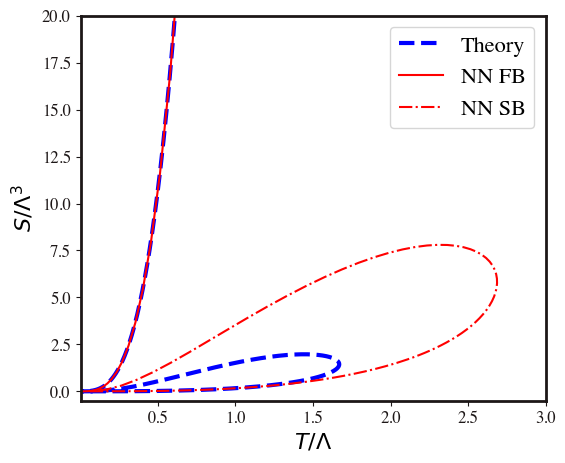

In [ ]:
# Data below has to be obtained from solving the direct problem with NN potential and reading off the solutions at the boundary of AdS
recovered_soft_path = f'{parent_dir}/SofT_recover_27M_1000_pts.txt'

recovered_soft_path_FB = None

theory_soft_path = f"{parent_dir}/Data/Potentials_phim/SofTphiM" + phim_str + ".txt"

# --- READ .txt FILES (FIX) ---
data_nn = np.loadtxt(recovered_soft_path)
T_nn = list(data_nn[:, 0])[::]
S_nn = list(data_nn[:, 1])[::]
print(len(S_nn))


i=0
T_nn_clean = []
S_nn_clean = []

for T,S in zip(T_nn, S_nn):
    if T<10**3 and S<10**9:
        T_nn_clean.append(T)
        S_nn_clean.append(S)
    i+=1
print(len(S_nn_clean))


### To split branches, easier in S/T^3 

s_over_T3_nn = np.array(S_nn_clean)/np.array(T_nn_clean)**3

# FIRST BRANCH and SECOND BRANCH SPLITTING

# SB
T_nn_SB = []
S_nn_SB = []

if recovered_soft_path_FB is not None:
    data_nn_FB = np.loadtxt(recovered_soft_path_FB)
    T_nn_FB = data_nn_FB[:, 0]
    S_nn_FB = data_nn_FB[:, 1]
else:
    T_nn_FB = []
    S_nn_FB = []
    flag_FB=True
    idx_FB_to_SB = None

    for j in range(1, len(T_nn_clean)):
        if np.abs(s_over_T3_nn[j-1] - s_over_T3_nn[j]) > 10:
            flag_FB = False
            if idx_FB_to_SB is None:
                idx_FB_to_SB = j

        if flag_FB == True:
            T_nn_FB.append(T_nn_clean[j])
            S_nn_FB.append(S_nn_clean[j])

        else:
            T_nn_SB.append(T_nn_clean[j])
            S_nn_SB.append(S_nn_clean[j])

    


T_nn_FB = T_nn_FB[::]
S_nn_FB = S_nn_FB[::]

T_nn_SB = np.array(T_nn_SB)
S_nn_SB = np.array(S_nn_SB)



data_th = np.loadtxt(theory_soft_path)
T_th = data_th[:, 0]
S_th = data_th[:, 1]

for j in range(len(T_th)-1):
    if T_th[j] - T_th[j+1] < 0:
        indx_th_SB = j
        break


C_UV_th = S_th[0]/T_th[0]**3

if max(T_th) < max(T_nn_FB):
    T_UV_th = np.linspace(max(T_th), max(T_nn_FB), 100)[::-1]
else:
    T_UV_th = np.linspace(max(T_nn_FB), max(T_th), 100)[::-1]

S_UV_th = C_UV_th * T_UV_th**3

T_th_UV_extra =  np.concatenate((T_UV_th, T_th))
S_th_UV_extra = np.concatenate((S_UV_th, S_th))




c_IR = S_nn_SB[-1]/T_nn_SB[-1]**3
T_IR = np.linspace(0.0, T_nn_SB[-1], 100)
# print('(T_SB, S_SB) min', T_nn_SB[idx_min_T_nn_SB], S_nn_SB[idx_min_T_nn_SB])
S_IR = c_IR * T_IR**3

T_IR = T_IR[2::-1]
S_IR = S_IR[2::-1]

T_nn_extra =  list(T_nn_SB)
S_nn_extra = list(S_nn_SB)

for T, S in zip(T_IR, S_IR):
    T_nn_extra.append(T)
    S_nn_extra.append(S)





fig = plt.figure(figsize = (6,5))

# plt.plot(T_th_UV_extra, S_th_UV_extra, label = 'Theory', color = 'blue', linestyle = 'dashed', linewidth=3, zorder=1)
plt.plot(T_th, S_th, label = 'Theory', color = 'blue', linestyle = 'dashed', linewidth=3, zorder=1)

# plt.scatter(T_th[0], S_th[0], label = 'Theory original', color = 'blue', s=50, zorder=1)
# plt.scatter(T_IR[0], S_IR[0], label='beg. of IR extension', color = 'orange', s=50)

plt.plot(T_nn_FB, S_nn_FB, label='NN FB', color = 'red', zorder=2, marker='.', markersize=0, linestyle='-')
plt.plot(T_nn_SB, S_nn_SB, label='NN SB', color = 'red', zorder=2, marker='.', markersize=0, linestyle='-.')

### Scatter plots ###
# plt.scatter(T_nn_FB, S_nn_FB, label='NN FB', color = 'green', s=20)
# plt.scatter(T_nn_SB, S_nn_SB, label='NN SB ', color = 'red', s=5, zorder=2)

### Checks for outliers ####
# for i in outliers_idx:
#     plt.scatter(T_nn_SB[i-1], S_nn_SB[i-1], label='outliers SB ', color = 'green', s=500, marker='+', zorder=1)

# plt.scatter(T_outliers, S_outliers, label='outliers SB ', color = 'k', s=100, marker='x', zorder=1)
# plt.scatter(T_nn_extra, S_nn_extra, label='NN SB extended', color = 'green', s=10)

# plt.plot(T_nn_SB, S_nn_SB, label='NN SB', color = 'red', zorder=2, marker='.', markersize=0, linestyle='-.')
# plt.plot(T_th_extra, S_th_extra, label = 'Theory', color = 'blue', linestyle = 'dashed')
# plt.axvline(min(min(T_th),min(T_nn)), linewidth=1, color='k', label=f'{min(min(T_th),min(T_nn)):.3f}')
# plt.plot(T_nn_clean[::3],S_nn_clean[::3], label='NN', color = 'black', zorder=3, marker='.', markersize=0.2, linestyle='-', linewidth=1)


plt.legend()
plt.xlabel(r'$T/\Lambda$')
plt.ylabel(r'$S/\Lambda^3$')
plt.xlim(left = min(T_th_UV_extra), right = 3.0)

# plt.xlim(left = max(min(T_th_UV_extra),min(T_nn_extra)), right = 3.5)
plt.ylim(bottom = -0.5, top = 20)
plt.show()

# fig.savefig(f'{plots_dir}/soft_phiM_' + phim_str + f'_NN_vs_th_epochs_{c.solver.global_epoch}_{type_str_for_saving}.pdf', bbox_inches="tight")

# fig.savefig(f'{plots_dir}/soft_phiM_' + phim_str + f'_NN_vs_th_epochs_{approx_epoch_num}_{type_str_for_saving}.pdf', bbox_inches="tight")



26.667735123512255 0.16085744114596695


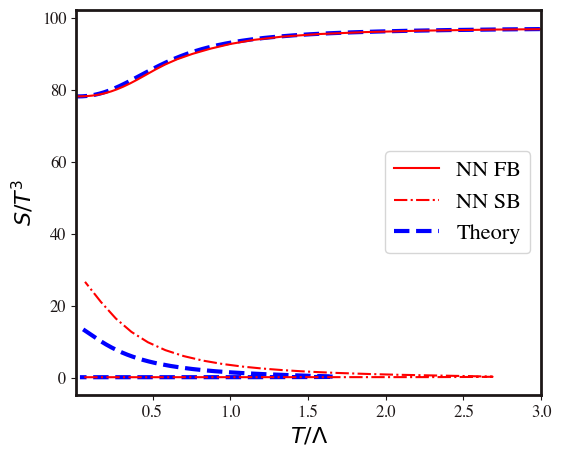

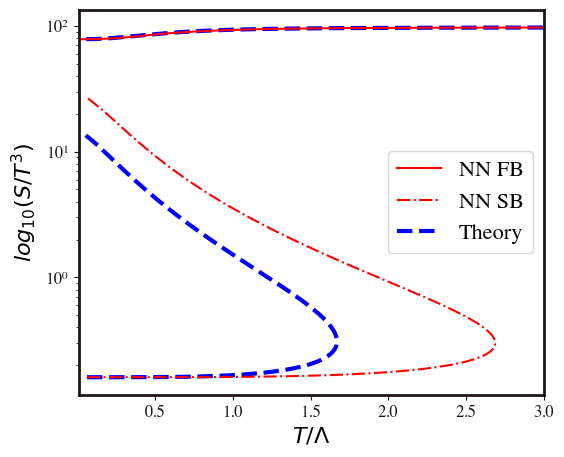

In [ ]:

T_nn = np.array(T_nn_clean)
S_nn = np.array(S_nn_clean)

s_over_T3_nn = S_nn/T_nn**3
s_over_T3_th = S_th/T_th**3
s_over_T3_th_UV_extra = np.array(S_th_UV_extra)/np.array(T_th_UV_extra)**3

T_th_FB = T_th[:indx_th_SB]
S_th_FB = S_th[:indx_th_SB]
s_over_T3_th_FB = S_th_FB/T_th_FB**3

T_th_SB = T_th[indx_th_SB+1:]
S_th_SB = S_th[indx_th_SB+1:]
s_over_T3_th_SB = S_th_SB/T_th_SB**3

s_over_T3_nn_FB = np.array(S_nn_FB)/np.array(T_nn_FB)**3
s_over_T3_nn_SB = np.array(S_nn_SB)/np.array(T_nn_SB)**3

# s_over_T3_nn_SB_extended =  np.array(S_nn_extra)/np.array(T_nn_extra)**3

c_IR_nn = s_over_T3_nn[-1]
c_IR_th = s_over_T3_th[-1]

print(c_IR_nn, c_IR_th)

T_nn_IR =  np.linspace(0, min(T_nn),100)
T_th_IR =  np.linspace(0, min(T_th),100)

s_over_T3_nn_IR = c_IR_nn * np.ones_like(T_nn_IR)
s_over_T3_th_IR = c_IR_th * np.ones_like(T_th_IR)

s_over_T3_nn_extra =  np.concatenate((s_over_T3_nn, s_over_T3_nn_IR))
s_over_T3_th_extra =  np.concatenate((s_over_T3_th, s_over_T3_th_IR))

T_nn_extra =  np.concatenate((T_nn, T_nn_IR))
T_th_extra =  np.concatenate((T_th, T_th_IR))



fig = plt.figure(figsize = (6,5))

### Line plots ###
plt.plot(T_nn_FB, s_over_T3_nn_FB, label='NN FB', color = 'red', zorder=2, marker='.', markersize=0, linestyle='-')
plt.plot(T_nn_SB, s_over_T3_nn_SB, label='NN SB', color = 'red', zorder=2, marker='.', markersize=0, linestyle='-.')
plt.plot(T_th_UV_extra[:indx_th_SB], s_over_T3_th_UV_extra[:indx_th_SB], label = 'Theory', color = 'blue', linestyle = 'dashed',linewidth=3, zorder=1)
# plt.plot(T_th, s_over_T3_th, label = 'Theory', color = 'blue', linestyle = 'dashed',linewidth=3, zorder=1)

# plt.plot(T_th_FB, s_over_T3_th_FB, label = 'Theory', color = 'blue', linestyle = 'dashed',linewidth=3, zorder=1)
plt.plot(T_th_SB, s_over_T3_th_SB, color = 'blue', linestyle = 'dashed',linewidth=3, zorder=1)
# plt.plot(T_nn_extra, s_over_T3_nn_SB_extended, label='NN SB extended', color = 'red', zorder=2, marker='.', markersize=0, linestyle='-.')

### Scatter plots ###
# plt.scatter(T_nn, s_over_T3_nn, s=25, label='NN', color = 'black', zorder=2)
# plt.scatter(T_nn_SB, s_over_T3_nn_SB, label='NN SB', color = 'red', s=10, zorder=2)
# plt.scatter(T_nn_FB, s_over_T3_nn_FB, label='NN FB', color = 'green', s=10, zorder=2)
# plt.scatter(T_IR[0], S_IR[0]/(c_IR* T_IR[0]**3), label='beg. of IR extension', color = 'orange', s=50)

plt.legend(loc='center right')
plt.xlabel(r'$T/\Lambda$')
plt.ylabel(r'$S/T^3$')
plt.xlim(left = max(min(T_th),min(T_nn)), right = 3.0)
# plt.ylim(bottom = -5, top = 100)
plt.show()

fig.savefig(f'{plots_dir}/soverT3_phiM_' + phim_str + f'_NN_vs_th_epochs_{c.solver.global_epoch}_{type_str_for_saving}.pdf', bbox_inches="tight")


fig = plt.figure(figsize = (6,5))

### Line plots ###
plt.plot(T_nn_FB, s_over_T3_nn_FB, label='NN FB', color = 'red', zorder=2, marker='.', markersize=0, linestyle='-')
plt.plot(T_nn_SB, s_over_T3_nn_SB, label='NN SB', color = 'red', zorder=2, marker='.', markersize=0, linestyle='-.')
plt.plot(T_th_UV_extra[:indx_th_SB], s_over_T3_th_UV_extra[:indx_th_SB], label = 'Theory', color = 'blue', linestyle = 'dashed',linewidth=3, zorder=1)
plt.plot(T_th_SB, s_over_T3_th_SB, color = 'blue', linestyle = 'dashed',linewidth=3, zorder=1)

# plt.plot(T_th, s_over_T3_th, label = 'Theory', color = 'blue', linestyle = 'dashed',linewidth=3, zorder=1)

plt.yscale('log')
plt.legend(loc='center right')
plt.xlabel(r'$T/\Lambda$')
plt.ylabel(r'$log_{10}(S/T^3)$')
plt.xlim(left = max(min(T_th),min(T_nn)), right = 3.0)
# plt.ylim(bottom = -5, top = 100)
plt.show()

# fig.savefig(f'{plots_dir}/log_soverT3_phiM_' + phim_str + f'_NN_vs_th_epochs_{c.solver.global_epoch}_{type_str_for_saving}.pdf', bbox_inches="tight")
# fig.savefig(f'{plots_dir}/log_soverT3_phiM_' + phim_str + f'_NN_vs_th_epochs_{approx_epoch_num}_{type_str_for_saving}.pdf', bbox_inches="tight")



### Errors for comparison of FB with Paper I

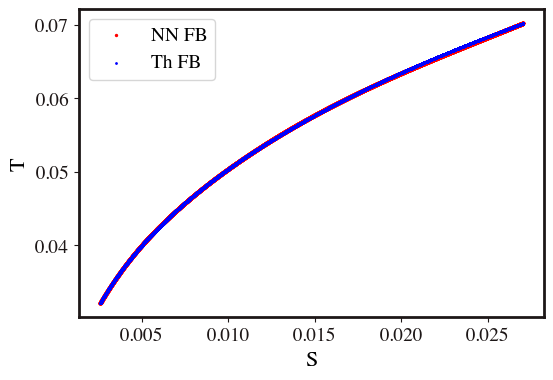

In [ ]:
n_points = 50000

UV_cut = 35
IR_cut = -8
# UV_cut = 30

# --- FB branch ---
x_nn_FB = np.array(S_nn_FB)[UV_cut:IR_cut]
y_nn_FB = np.array(T_nn_FB)[UV_cut:IR_cut]

x_th_FB = np.array(S_th_FB)
y_th_FB = np.array(T_th_FB)

# Overlap domain
x_min_FB = max(x_nn_FB.min(), x_th_FB.min())
x_max_FB = min(x_nn_FB.max(), x_th_FB.max())

x_common_FB = np.linspace(x_min_FB, x_max_FB, n_points)

# Interpolation
y_nn_interp_FB = interp1d(x_nn_FB, y_nn_FB, kind='cubic')
y_th_interp_FB = interp1d(x_th_FB, y_th_FB, kind='cubic')

y_nn_common_FB = y_nn_interp_FB(x_common_FB)
y_th_common_FB = y_th_interp_FB(x_common_FB)

# Relative error
RE_FB = np.abs(y_nn_common_FB - y_th_common_FB) / (np.abs(y_th_common_FB) + 1e-12)


# # # --- SB branch ---
# x_nn_SB = s_over_T3_nn_SB
# y_nn_SB = T_nn_SB

# x_th_SB = s_over_T3_th_SB
# y_th_SB = T_th_SB

# # Overlap domain
# x_min_SB = max(x_nn_SB.min(), x_th_SB.min())
# x_max_SB = min(x_nn_SB.max(), x_th_SB.max())

# x_common_SB = np.linspace(x_min_SB, x_max_SB, n_points)

# # Interpolation
# y_nn_interp_SB = interp1d(x_nn_SB, y_nn_SB)
# y_th_interp_SB = interp1d(x_th_SB, y_th_SB)

# y_nn_common_SB = y_nn_interp_SB(x_common_SB)
# y_th_common_SB = y_th_interp_SB(x_common_SB)

# # Relative error
# RE_SB = np.abs(y_nn_common_SB - y_th_common_SB) / (np.abs(y_th_common_SB) + 1e-12)


plt.figure(figsize=(6,4))

# FB
plt.scatter(x_common_FB, y_nn_common_FB, s=2, label='NN FB', color='red')
plt.scatter(x_common_FB, y_th_common_FB, s=1, label='Th FB', color='blue')

# SB
# plt.scatter(x_common_SB, y_nn_common_SB, s=2, label='NN SB', color='green')
# plt.scatter(x_common_SB, y_th_common_SB, s=1, label='Th SB', color='orange')

plt.legend()
plt.xlabel('S')
plt.ylabel('T')
plt.show()


In [ ]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 20,
    'axes.labelsize': 16,
    'legend.fontsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'mathtext.fontset': 'dejavusans'
})

rms= 0.0941765239697227 %


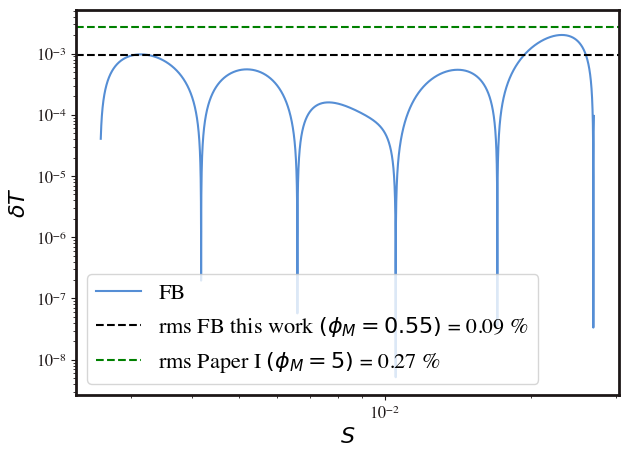

Mean RE FB 0.06892995921326356 %
Max RE FB 0.20178244601281697 %


In [ ]:
rms = np.sqrt(np.mean(RE_FB[:]**2))
rms_paper1_phiM_5 = 0.27 / 100 # from paper I

fig = plt.figure(figsize=(7,5))
gap = 0

plt.plot((x_common_FB-gap*np.ones_like(x_common_FB))[:], RE_FB[:], label=rf'FB', color='C1')
# plt.plot(x_common_SB[1::], RE_SB[1::], label='SB', color='C1')

plt.axhline(rms, color='k', linestyle='dashed', label = fr'rms FB this work $(\phi_M = 0.55)$ = {rms*100:.2f} %')
plt.axhline(rms_paper1_phiM_5, color='green', linestyle='dashed', label = rf'rms Paper I $(\phi_M = 5)$ = {rms_paper1_phiM_5*100:.2f} %')
plt.yscale('log')
plt.xscale('log')
plt.legend()
# plt.xlabel(r'$S/T^3$')
plt.ylabel(r'$\delta T$')
plt.xlabel(r'$S$')

print('rms=', rms*100, '%')
# fig.savefig(f'{plots_dir}/RE_sofT_phiM_' + phim_str + f'_epochs_{epochs}_no_grid_{type_str_for_saving}.pdf', bbox_inches="tight")

plt.show()

print('Mean RE FB', np.mean(RE_FB)*100, '%')
# print('Mean RE SB', np.mean(RE_SB)*100, '%')

print('Max RE FB', RE_FB[1::].max()*100, '%')
# print('Max RE SB', RE_SB[1::].max()*100, '%')

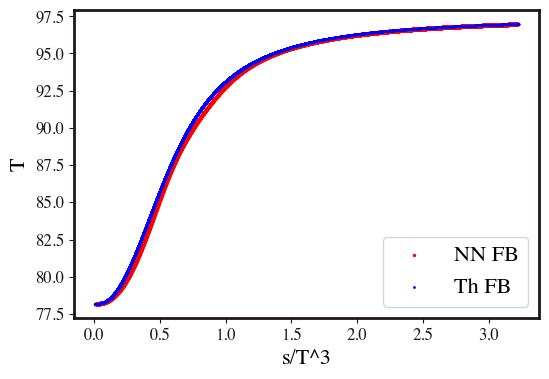

In [ ]:
n_points = 10000

# --- FB branch ---
y_nn_FB = np.array(s_over_T3_nn_FB)
x_nn_FB = np.array(T_nn_FB)

y_th_FB = np.array(s_over_T3_th_FB)
x_th_FB = np.array(T_th_FB)

# Overlap domain
x_min_FB = max(x_nn_FB.min(), x_th_FB.min())
x_max_FB = min(x_nn_FB.max(), x_th_FB.max())

x_common_FB = np.linspace(x_min_FB, x_max_FB, n_points)

# Interpolation
y_nn_interp_FB = interp1d(x_nn_FB, y_nn_FB,kind='cubic')
y_th_interp_FB = interp1d(x_th_FB, y_th_FB,kind='cubic')

y_nn_common_FB = y_nn_interp_FB(x_common_FB)
y_th_common_FB = y_th_interp_FB(x_common_FB)

# Relative error
RE_FB = np.abs(y_nn_common_FB - y_th_common_FB) / (np.abs(y_th_common_FB) + 1e-12)


# # --- SB branch ---
# x_nn_SB = s_over_T3_nn_SB
# y_nn_SB = T_nn_SB

# x_th_SB = s_over_T3_th_SB
# y_th_SB = T_th_SB

# # Overlap domain
# x_min_SB = max(x_nn_SB.min(), x_th_SB.min())
# x_max_SB = min(x_nn_SB.max(), x_th_SB.max())

# x_common_SB = np.linspace(x_min_SB, x_max_SB, n_points)

# # Interpolation
# y_nn_interp_SB = interp1d(x_nn_SB, y_nn_SB)
# y_th_interp_SB = interp1d(x_th_SB, y_th_SB)

# y_nn_common_SB = y_nn_interp_SB(x_common_SB)
# y_th_common_SB = y_th_interp_SB(x_common_SB)

# # Relative error
# RE_SB = np.abs(y_nn_common_SB - y_th_common_SB) / (np.abs(y_th_common_SB) + 1e-12)


plt.figure(figsize=(6,4))

# FB
plt.scatter(x_common_FB, y_nn_common_FB, s=2, label='NN FB', color='red')
plt.scatter(x_common_FB, y_th_common_FB, s=1, label='Th FB', color='blue')

# SB
# plt.scatter(x_common_SB, y_nn_common_SB, s=2, label='NN SB', color='green')
# plt.scatter(x_common_SB, y_th_common_SB, s=1, label='Th SB', color='orange')

plt.legend()
plt.xlabel('s/T^3')
plt.ylabel('T')
plt.show()


rms= 0.33045810939687775 %


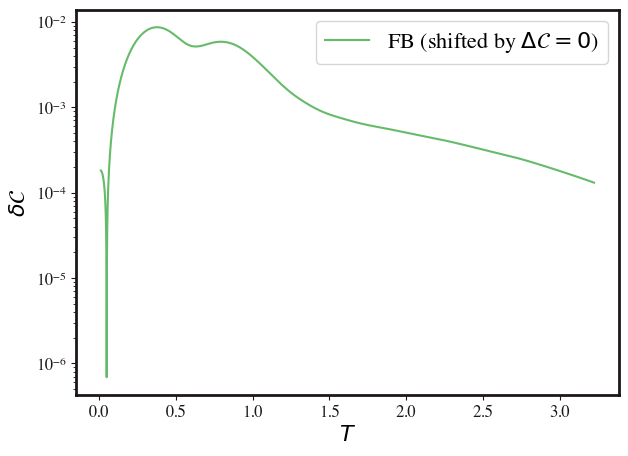

Mean RE FB 0.21163761097769238 %
Max RE FB 0.8666770627697113 %


In [ ]:
fig = plt.figure(figsize=(7,5))
gap = 0
plt.plot((x_common_FB-gap*np.ones_like(x_common_FB))[4:], RE_FB[4:], label=rf'FB (shifted by $\Delta \mathcal{{C}}={gap}$)', color='C0')
# plt.plot(x_common_SB[1::], RE_SB[1::], label='SB', color='C1')
plt.yscale('log')
# plt.xscale('log')

plt.legend()
# plt.xlabel(r'$S/T^3$')
plt.ylabel(r'$\delta\mathcal{C}$')
plt.xlabel(r'$ T$')

print('rms=', np.sqrt(np.mean(RE_FB[4:]**2))*100, '%')
# fig.savefig(f'{plots_dir}/RE_sofT_phiM_' + phim_str + f'_epochs_{epochs}_no_grid_{type_str_for_saving}.pdf', bbox_inches="tight")

plt.show()

print('Mean RE FB', np.mean(RE_FB)*100, '%')
# print('Mean RE SB', np.mean(RE_SB)*100, '%')

print('Max RE FB', RE_FB[1::].max()*100, '%')
# print('Max RE SB', RE_SB[1::].max()*100, '%')

### Error for FB and SB with the metrics of paper II

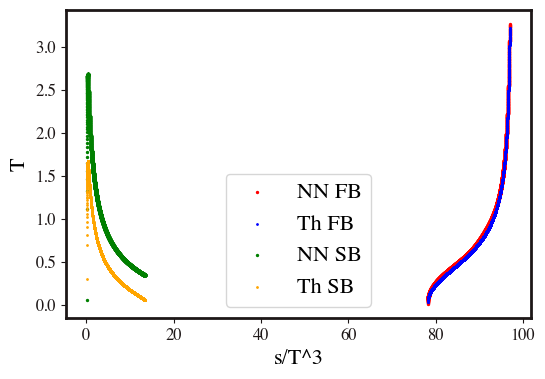

In [ ]:
n_points = 10000

# --- FB branch ---
x_nn_FB = s_over_T3_nn_FB
y_nn_FB = T_nn_FB

x_th_FB = s_over_T3_th_FB
y_th_FB = T_th_FB

# Overlap domain
x_min_FB = max(x_nn_FB.min(), x_th_FB.min())
x_max_FB = min(x_nn_FB.max(), x_th_FB.max())

x_common_FB = np.linspace(x_min_FB, x_max_FB, n_points)

# Interpolation
y_nn_interp_FB = interp1d(x_nn_FB, y_nn_FB,kind='cubic')
y_th_interp_FB = interp1d(x_th_FB, y_th_FB,kind='cubic')

y_nn_common_FB = y_nn_interp_FB(x_common_FB)
y_th_common_FB = y_th_interp_FB(x_common_FB)

# Relative error
RE_FB = np.abs(y_nn_common_FB - y_th_common_FB) / (np.abs(y_th_common_FB) + 1e-12)


# # --- SB branch ---
x_nn_SB = s_over_T3_nn_SB
y_nn_SB = T_nn_SB

x_th_SB = s_over_T3_th_SB
y_th_SB = T_th_SB

# Overlap domain
x_min_SB = max(x_nn_SB.min(), x_th_SB.min())
x_max_SB = min(x_nn_SB.max(), x_th_SB.max())

x_common_SB = np.linspace(x_min_SB, x_max_SB, n_points)

# Interpolation
y_nn_interp_SB = interp1d(x_nn_SB, y_nn_SB, kind='cubic')
y_th_interp_SB = interp1d(x_th_SB, y_th_SB, kind='cubic')

y_nn_common_SB = y_nn_interp_SB(x_common_SB)
y_th_common_SB = y_th_interp_SB(x_common_SB)

# Relative error
RE_SB = np.abs(y_nn_common_SB - y_th_common_SB) / (np.abs(y_th_common_SB) + 1e-12)


plt.figure(figsize=(6,4))

# FB
plt.scatter(x_common_FB, y_nn_common_FB, s=2, label='NN FB', color='red')
plt.scatter(x_common_FB, y_th_common_FB, s=1, label='Th FB', color='blue')

# SB
plt.scatter(x_common_SB, y_nn_common_SB, s=2, label='NN SB', color='green')
plt.scatter(x_common_SB, y_th_common_SB, s=1, label='Th SB', color='orange')

plt.legend()
plt.xlabel('s/T^3')
plt.ylabel('T')
plt.show()


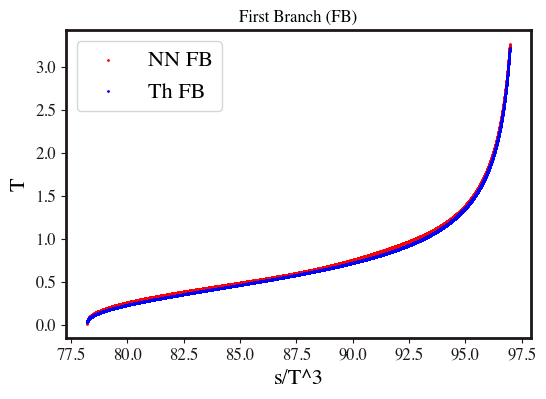

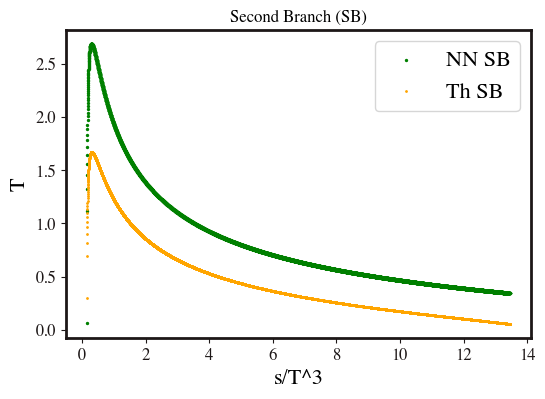

In [ ]:
# # --- FB ---
plt.figure(figsize=(6,4))
plt.scatter(x_common_FB, y_nn_common_FB, s=1, label='NN FB', color='red')
plt.scatter(x_common_FB, y_th_common_FB, s=1, label='Th FB', color='blue')
plt.legend()
plt.title('First Branch (FB)')
plt.xlabel('s/T^3')
plt.ylabel('T')
plt.show()

# --- SB ---
plt.figure(figsize=(6,4))
plt.scatter(x_common_SB, y_nn_common_SB, s=2, label='NN SB', color='green')
plt.scatter(x_common_SB, y_th_common_SB, s=1, label='Th SB', color='orange')
plt.legend()
plt.title('Second Branch (SB)')
plt.xlabel('s/T^3')
plt.ylabel('T')
plt.show()

In [ ]:
plots_dir
type_str_for_saving

'FB_new_fv_0_69'

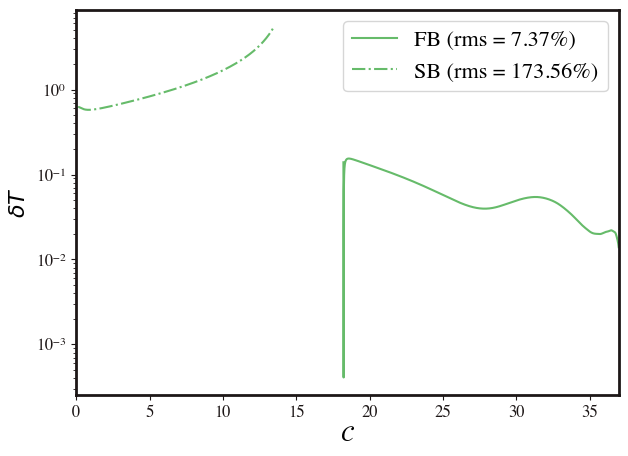

rms FB= 7.305299172308804 %
Mean RE FB 6.3226202996766 %
Mean RE SB 141.62843678965382 %
Max RE FB 15.43260268321104 %
Max RE SB 538.5123672419157 %


In [ ]:
rms_FB = np.sqrt(np.mean(RE_FB[:]**2))
rms_SB = np.sqrt(np.mean(RE_SB[:]**2))




fig = plt.figure(figsize=(7,5))
gap = 60
plt.plot((x_common_FB-gap*np.ones_like(x_common_FB))[5:], RE_FB[5:], label=rf'FB (rms = {rms_FB*100:.2f}%)', color='C0')
plt.plot(x_common_SB[1:], RE_SB[1:], linestyle = '-.', label= fr'SB (rms = {rms_SB*100:.2f}%)', color='C0')
plt.yscale('log')
# plt.xscale('log')

plt.legend(loc='upper right')
# plt.xlabel(r'$S/T^3$')
plt.xlabel(r'$\mathcal{C}$')
plt.ylabel(r'$\delta T$')
plt.xlim(left=0, right=max((x_common_FB-gap*np.ones_like(x_common_FB))[5:]))

# fig.savefig(f'{plots_dir}/RE_sofT_phiM_' + phim_str + f'_epochs_{c.solver.global_epoch}_no_grid_{type_str_for_saving}.pdf', bbox_inches="tight")
# fig.savefig(f'{plots_dir}/RE_sofT_phiM_' + phim_str + f'_epochs_{approx_epoch_num}_no_grid_{type_str_for_saving}.pdf', bbox_inches="tight")


plt.show()
print('rms FB=', np.sqrt(np.mean(RE_FB[5:]**2))*100, '%')


print('Mean RE FB', np.mean(RE_FB[5:])*100, '%')
print('Mean RE SB', np.mean(RE_SB)*100, '%')

print('Max RE FB', RE_FB[5:].max()*100, '%')
print('Max RE SB', RE_SB[:].max()*100, '%')

### $\phi(u)$ for both branches

In [ ]:
phi_solutions_FB = np.load(f'{os.getcwd()}/FB_results/phi_solutions_FB_1968648.npy', allow_pickle=True)
sofT_for_NN_FB = np.array(np.load(f'{os.getcwd()}/FB_results/sofT_FB_1968648.npy', allow_pickle=True)).T

In [ ]:

print(sofT_for_NN_FB.shape)

(70, 2)


<Figure size 500x400 with 0 Axes>

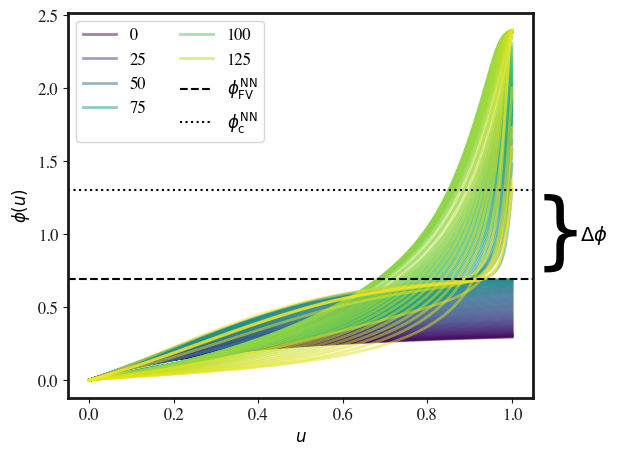

In [ ]:
d = c
sb = c

u = torch.linspace(0,1,250)
# u = np.linspace(0,1,250)
var_names = ['Vs', 'Va', 'Vp', r'$\Sigma$', 'A', r'$\phi$']

fig= plt.figure(figsize=(5,4))

step = 1


phi_solutions = phi_solutions_FB
phi_last = phi_solutions_FB[-1][-1]



u = torch.linspace(0,1,250)


phi_solutions_SB = []
step = step

j = 5  # phi solution
for i in range(len(sb.Va_uh_all)):
    
    S = d.Sigma_uh_all[i] * torch.ones_like(u,  dtype=torch.float64)
    T = d.Va_uh_all[i] * torch.ones_like(u, dtype=torch.float64)
    Z = d.Z[i] * torch.ones_like(u, dtype=torch.float64)
    sol = sb.solver.get_solution(best = True)

        
    # u = u.astype(np.float32)
    # S = S.astype(np.float32)
    # T = T.astype(np.float32)
    # Z = Z.astype(np.float32)

    phi_sol = sol(u,S,T,Z)[j]
    #  RES.append(torch.stack(res).mean(dim = 0))
    phi_solutions_SB.append(phi_sol.cpu().detach().numpy())

phi_first_SB = phi_solutions_SB[0][-1]





num_curves_FB = len(d.Va_uh_all)
num_curves_SB = len(sb.Va_uh_all)

num_curves = num_curves_FB + num_curves_SB

cmap = cm.get_cmap('viridis', num_curves)
norm = mcolors.Normalize(vmin=0, vmax=num_curves - 1)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])


plt.rcParams["text.usetex"] = False


fig = plt.figure(figsize=(6,5))

color_list = []
for i in range(num_curves):
    #if i == step:# == 0:
    if i % step == 0:

        col = cmap(i / (num_curves - 1))
        
        y = u.cpu().detach().numpy()
        if i < num_curves_FB: 
            z = phi_solutions[i]
        else:
            z = phi_solutions_SB[i-num_curves_FB]

        color_list.append(col)

        if i % 25 == 0:

            plt.plot(y, z, color=col, linewidth=2, label = i, alpha = 0.5)

        else:
            plt.plot(y, z, color=col, linewidth=2, alpha = 0.5)


# plt.colorbar(mappable=np.array(color_list))
# plt.scatter(1.0, phi_last, c = 'k', s=20)


plt.axhline(phi_last, linestyle = 'dashed', linewidth=1.5, color = 'k', label = r'$\phi_\text{FV}^\text{NN} $') # +f'{phi_last:.2f}')
plt.axhline(phi_first_SB, linestyle = 'dotted', linewidth=1.5, color = 'k', label = r'$\phi_\text{c}^\text{NN} $') # +f'{phi_first_SB:.2f}')

plt.xlabel(r'$u$')
plt.ylabel(r'$\phi(u)$')
plt.legend(loc='upper left', ncol = 2)


# --- coordinates ---
y1 = phi_first_SB
y2 = phi_last
x_brace = 1.0  # slightly outside the right axis (in axes fraction)

# Convert data y-coordinates to axis fraction
ymin, ymax = plt.gca().get_ylim()
y1_ax = (y1 - ymin) / (ymax - ymin)
y2_ax = (y2 - ymin) / (ymax - ymin)
y_center_ax = 0.5 * (y1_ax + y2_ax)
height_ax = abs(y2_ax - y1_ax)


# Draw vertical brace
plt.text(
    x_brace,
    y_center_ax,
    r"$\}$",
    transform=plt.gca().transAxes,
    fontsize=60,  # scale brace with gap
    va='center',
    ha='left',
)

# Add Delta phi label
plt.text(
    x_brace + 0.1,
    y_center_ax,
    rf"$\Delta \phi$",
    transform=plt.gca().transAxes,
    fontsize=14,
    va='center',
    ha='left'
)
plt.show()


# fig.savefig(f'{plots_dir}/phi_u_0_8_FB_and_SB_fix_bug.pdf', bbox_inches='tight')


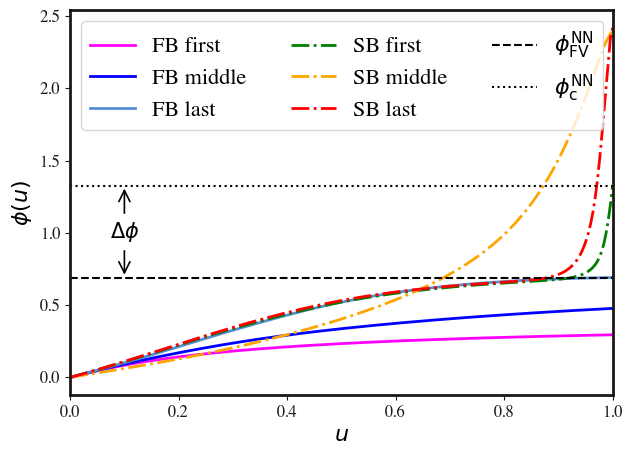

-0.6340598862693809
1.3256208699272178


In [ ]:

phi_for_plot = [phi_solutions[0], phi_solutions[num_curves_FB//2], phi_solutions[-1], phi_solutions_SB[0], phi_solutions_SB[num_curves_SB//2], phi_solutions_SB[-1]]

cmap = cm.get_cmap('viridis', num_curves)
norm = mcolors.Normalize(vmin=0, vmax=num_curves - 1)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])


solution_labels = ['FB first', 'FB middle', 'FB last', 'SB first', 'SB middle', 'SB last']
color_list = ['magenta', 'blue', 'C1', 'green', 'orange', 'red']


linestyles = ['-', '-.']

fig = plt.figure(figsize=(7,5))

for i,phi in enumerate(phi_for_plot):
    #if i == step:# == 0:

    # if i<3:
    #     cmap = cm.get_cmap('Blues', 3)
    # else:
    #     cmap = cm.get_cmap('Reds', 3)


    # cmap = cm.get_cmap('gist_rainbow_r', len(phi_for_plot))
    # col = cmap(i/(6-1))
    col = color_list[i]

    y = u.cpu().detach().numpy()
    z = phi

    if i<3:
        lin = linestyles[0]
    else:
        lin = linestyles[1]

    plt.plot(y, z, color=col, linewidth=2, label = solution_labels[i], alpha = 1, linestyle = lin)


plt.axhline(phi_last, linestyle = 'dashed', linewidth=1.5, color = 'k', label = r'$\phi_\text{FV}^\text{NN} $') # +f'{phi_last:.2f}')
plt.axhline(phi_first_SB, linestyle = 'dotted', linewidth=1.5, color = 'k', label = r'$\phi_\text{c}^\text{NN} $') # +f'{phi_first_SB:.2f}')

plt.xlabel(r'$u$')
plt.ylabel(r'$\phi(u)$')
plt.legend(loc='upper left', ncol = 3)
plt.xlim(left=0 ,right=1)




# --- coordinates ---
y1 = phi_first_SB
y2 = phi_last

x_mid = 0.1

ax = plt.gca()

# Convert to axis coordinates
ymin, ymax = ax.get_ylim()

y1_ax = (y1 - ymin) / (ymax - ymin)
y2_ax = (y2 - ymin) / (ymax - ymin)

y_center_ax = 0.5 * (y1_ax + y2_ax)

# gap around label
gap = 0.0

# --- lower arrow ---
ax.annotate(
    '',
    xy=(x_mid, y1_ax),                    # arrow tip
    xytext=(x_mid, y_center_ax - gap),   # start
    xycoords=ax.transAxes,
    textcoords=ax.transAxes,
    arrowprops=dict(
        arrowstyle='->',
        linewidth=1.2,
        color='k'
    )
)

# --- upper arrow ---
ax.annotate(
    '',
    xy=(x_mid, y2_ax),                    # arrow tip
    xytext=(x_mid, y_center_ax + gap),    # start
    xycoords=ax.transAxes,
    textcoords=ax.transAxes,
    arrowprops=dict(
        arrowstyle='->',
        linewidth=1.2,
        color='k'
    )
)

# --- label ---
ax.text(
    x_mid,
    y_center_ax,
    r'$\Delta \phi$',
    transform=ax.transAxes,
    fontsize=15,
    va='center',
    ha='center',
    backgroundcolor='white'
)

plt.show()

# fig.savefig(f'{plots_dir}/phi_u_0_55_FB_and_SB_few_curves_epoch_{c.solver.global_epoch}.pdf', bbox_inches='tight')
# fig.savefig(f'{plots_dir}/phi_u_0_55_FB_and_SB_few_curves_epoch_{approx_epoch_num}.pdf', bbox_inches='tight')

#
print(phi_last-phi_first_SB)
print(phi_first_SB)
